In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})
ds

<xarray.Dataset> Size: 891MB
Dimensions:     (xi_rho: 602, xi_u: 601, eta_rho: 542, eta_v: 541, s_rho: 32,
                 s_w: 33, time: 1, auxil: 4)
Coordinates: (12/13)
  * xi_rho      (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * xi_u        (xi_u) float64 5kB 1.5 2.5 3.5 4.5 ... 598.5 599.5 600.5 601.5
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 540.0 541.0 542.0
  * eta_v       (eta_v) float64 4kB 1.5 2.5 3.5 4.5 ... 538.5 539.5 540.5 541.5
  * s_rho       (s_rho) float64 256B -0.9844 -0.9531 ... -0.04688 -0.01562
  * s_w         (s_w) float64 264B -1.0 -0.9688 -0.9375 ... -0.0625 -0.03125 0.0
    ...          ...
    lat_rho     (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(542, 602), meta=np.ndarray>
    lon_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lat_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lon_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
    lat_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
  * time        (time) float32 4B 1.339e+06
Dimensions without coordinates: auxil
Data variables: (12/54)
    spherical   |S1 1B ...
    xl          float64 8B ...
    el          float64 8B ...
    Vtransform  float64 8B ...
    sc_r        (s_rho) float64 256B dask.array<chunksize=(32,), meta=np.ndarray>
    sc_w        (s_w) float64 264B dask.array<chunksize=(33,), meta=np.ndarray>
    ...          ...
    swflux      (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    radsw       (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_rlw   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_lat   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_sen   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    hel         (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
Attributes: (12/57)
    type:           ROMS restart file
    title:          Peru UW Interannual Run
    date:           
    rst_file:       croco_rst.nc
    his_file:       croco_his.nc
    avg_file:       croco_avg.nc
    ...             ...
    gamma2_expl:    Slipperiness parameter
    x_sponge:       0.0
    v_sponge:       0.0
    sponge_expl:    Sponge parameters : extent (m) & viscosity (m2.s-1)
    SRCS:           main.F step.F read_inp.F timers_roms.F init_scalars.F ini...
    CPP-options:    REGIONAL PERU_UW MPI OBC_WEST OBC_NORTH OBC_SOUTH BIOLOGY...

In [3]:
ds.lon_rho.compute().values[0,:].shape
ds.lat_rho.compute().values[:,0].shape

(542,)

## Functions

In [4]:
## Functions
## kml to struct
def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [5]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

## Lon and lat for the whole dataset
lat = np.linspace(-33.0, 10.03286, 542).reshape(542, 1)  # Reshape to match eta_rho
lon = np.linspace(-118.9083, -68.90833, 602).reshape(1, 602)  # Reshape to match xi_rho

lats, lons = np.meshgrid(lat.flatten(), lon.flatten(), indexing="ij")

LON=lons
LAT=lats
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

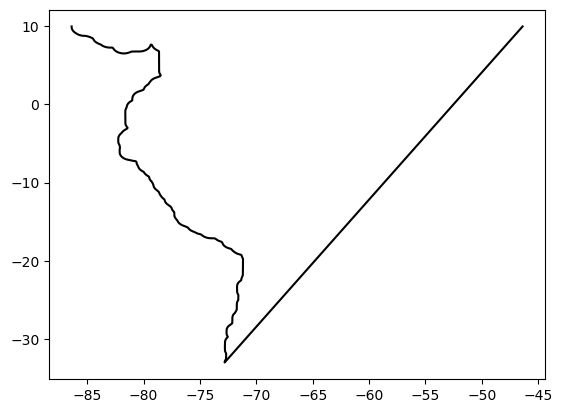

In [6]:
plt.plot(lonb1,latb1,color='black')

In [7]:
Puertos = {
    # "Inglés": [-17.65611111,  -71.35083333],
    # "Ilo": [-17.64138889, -71.34777778],
    # "Pacocha":[-17.28,    -71.34333333],
    # "Mollendo":   [-17.03722222,  -72.00416667],
    # #"Matarani":  [-16.99583333,  -72.105],
    # "Quilca": [-16.71166667,  -72.43333333],
    # "La Planchada":   [-16.40472222,  -73.21277778],
    # "Camana":     [-16.64722222,  -72.70055556],
    # "Ilo":    [-17.63388889,  -71.33944444],
    # "M. Sama":    [-17.97166667,  -70.89027778],
    # "L. Palos":   [-18.27638889,  -70.47555556],
    # "Atico":  [-16.22388889,  -73.69916667],
    # "Chala":  [-15.81555556,  -74.42166667],
    # "Punta Infiernillos": [-14.52,    -75.9],
    # "Punta Caballa":  [-14.94972222,  -75.49833333],
    # "San Juan":   [-15.36638889, -75.17055556],
    # #"Lomas": [-15.55777778,  -74.85],
    # "San Juan":   [-15.34888889,  -75.16027778],
    # "San Nicolás":    [-15.25,    -75.24166667],
    # "Bahia Independencia": [-14.2522222222222, -76.1347222222222],
    #"General San Martín": [-13.8, -76.28916667],
    "Pisco":  [-13.69388889,  -76.22416667],
    # "Tambo de Mora":[-13.455, -76.18972222],
    # "Cerro Azul":   [-13.02055556,  -76.48555556],
    # #"Bujama":  [-12.7225,  -77.62944444],
    # "Pucusana":[-12.4977777777778,  -76.7952777777778],
    # "Chorrillos":[-12.15638889, -77.03194444],
    "Callao":   [-12.0575,  -77.15305556],
    # "Ancón":    [-11.76416667,  -77.17694444],
    # "Chancay":  [-11.575,   -77.27361111],
    # "Huacho":   [-11.11055556,  -77.62027778],
    # #"Carquín": [-11.08166667,  -77.63333333],
    # "Vegeta":   [-11,   -77.675],
    # "Supe": [-11.4758333333333, -77.50],
    # "Barranca":[-10.76222222,   -77.76583333],
    # "Punta Bermejo":[-10.4730555555556, -77.9661111111111],
    # "Las Zorras":[-10.2686111111111, -78.0788888888889],
    # "Huarmey":[-10.08916667,    -78.17166667],
    # "Culebras"  :[-9.945,   -78.23333333],
    # #"Tortugas":    [-9.337777778,  -77.405],
    # "Samanco":  [-9.237777778,  -78.50277778],
    "Chimbote": [-9.076666667,  -78.61472222],
    #"Santa":   [-8.977777778,  -78.65333333],
    # "Punta Chao":[-8.74138888888889,-78.7497222222222],
    # #"Coscobamba":   [-8.656944444,  -78.76111111],
    # "Casma" :[-9.43694444444444,    -78.385],
    # "Guañape":  [-8.416666667,  -78.89388889],
    # "Salaverry":    [-8.224444444,  -78.98166667],
    # "Huanchaco":    [-8.073333333,  -79.12333333],
    # "Chicama"   :[-7.703611111, -79.45916667],
    # "Pacasmayo":[-7.386944444,  -79.58833333],
    # "Chérrepe": [-7.153333333,  -79.70166667],
    # #"Lagunas":[-7.088333333,   -79.73055556],
    # "Eten": [-6.943333333,  -79.87972222],
    # #"Santa Rosa":  [-6.896666667,  -79.94166667],
    # "Pimentel": [-6.847777778,  -79.95583333],
    # #"San José":    [-6.798333333,  -79.99166667],
    # "Morrope":[-6.55027777777778,-80.2438888888889],
    # "Punta La Negra":[-5.98,-81.1491666666667],
    # "Mancora":  [-5.79, -81.06083333],
    # #"Parachique":[-5.67,-80.838333],
    # "Sechura":[-5.55694,-80.82222],
    # "Punta Gobernador":[-5.3144,-81.1050],
    "Paita":    [-5.078055556,  -81.10638889],
    # "Negritos": [-4.644166667,  -81.32222222],
    # #"Talara":  [-4.570277778,  -81.27972222],
    # "Lobitos":  [-4.4375,   -81.28416667],
    # "Cabo Blanco":  [-4.242777778,  -81.22888889],
    # "Los Órganos":  [-4.171944444,  -81.13333333],
    # "Cancas":   [-3.943611111,  -80.94388889],
    # "Zorritos": [-3.685277778,  -80.67138889],
    # "Puerto Pizarro":   [-3.513055556,  -80.40333333]
    }

In [8]:
##Normalize
def normalize(data):
    return (data - data.min()) / (data.max() - data.min())

## Load the Indices

### CUI

/tmp/ipykernel_924309/2666954542.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start='1980-01', end='2016-01', freq='M')


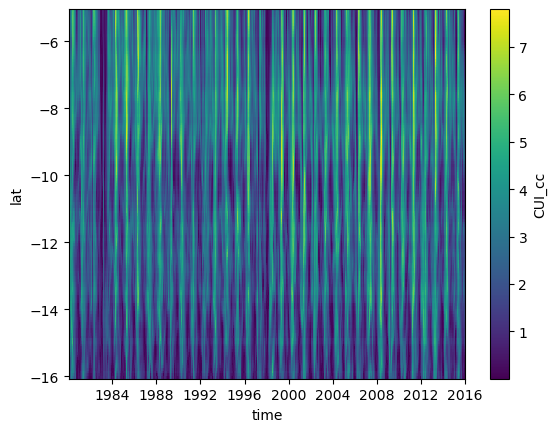

In [9]:
## generate time
time = pd.date_range(start='1980-01', end='2016-01', freq='M')
##CUI_model
CUI_db = loadmat("../../NHCS/Processed/CUI_SST_index.mat")
CUI_cc = np.array(CUI_db['CUI_SSTi']).squeeze()
lati_cc = np.array(CUI_db['lati']).squeeze()
#print(CUI.keys())
CUI_cc.shape

CUI_ds = xr.DataArray(
    data=CUI_cc.T,  # numpy array of Mean_CUI
    dims=["time",'lat'],  # Dimension matches the time in CUI_MAX
    coords={"time": time,
           'lat': lati_cc},  # Ensure matching time coordinates
    name="CUI_cc"  # Name for the variable
)

CUI_ds.sel(lat=CUI_ds['lat'] >-16.1).plot(y='lat')

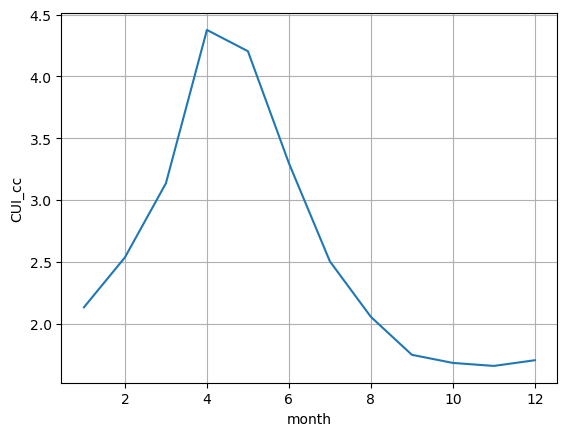

In [10]:
CUI_cut = CUI_ds.sel(lat=CUI_ds['lat'] >-16)
CUI_mmean = CUI_cut.mean(dim='lat',skipna=True).groupby('time.month').mean(dim='time')
CUI_anomaly = CUI_cut.mean(dim='lat', skipna=True).groupby('time.month') - CUI_mmean

CUI_mmean.plot()
plt.grid(True)


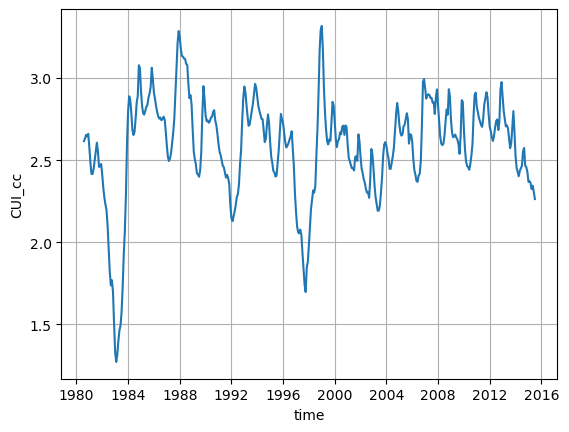

In [11]:
CUI_ts=CUI_cut.mean(dim=('lat'),skipna=True).rolling(time=13,center=True).mean()
CUI_ts.plot()
plt.grid(True)

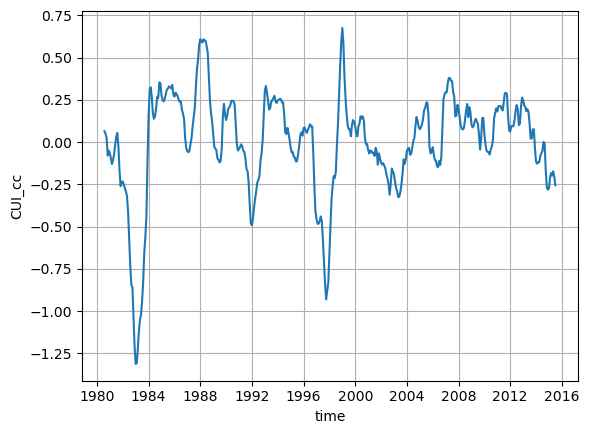

In [12]:
CUI_anomaly.rolling(time=13,center=True).mean().plot()
plt.grid(True)

### EKMAN

In [13]:
## Ekman pump
Ekman_data = loadmat("../../NHCS/Processed/EKMAN_components.mat")
# Ekman_data2 = loadmat("../../NHCS/Processed/Ekman_pump_2.mat") #calculated with formula
Ek_pump = Ekman_data['EK_pump']
# ## Ekman transport
Ek_tr = Ekman_data['UEK']*-1

Ek_pump.shape #lon, lat, time

(602, 542, 432)

In [14]:
EK_ds = xr.Dataset(
    data_vars={
        'Ekman_pump': (("time", "lat","lon"), Ek_pump.transpose(2, 1, 0)),
        'Ekman_transport':(("time", "lat","lon"), Ek_tr.transpose(2, 1, 0))
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

EK_ds

<xarray.Dataset> Size: 2GB
Dimensions:          (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon              (lon) float64 5kB -119.0 -118.9 -118.8 ... -68.95 -68.87
  * lat              (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.869 9.951 10.03
  * time             (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
Data variables:
    Ekman_pump       (time, lat, lon) float64 1GB 3.175e-07 4.708e-07 ... nan
    Ekman_transport  (time, lat, lon) float64 1GB -0.09788 -0.102 ... nan nan

In [15]:
EK_ds['Ekman_pump'] = EK_ds['Ekman_pump'] * inshore_mask
EK_ds['Ekman_transport'] = EK_ds['Ekman_transport'] * inshore_mask

EK_pump = EK_ds['Ekman_pump'].where((EK_ds.lat >= -16) & (EK_ds.lat <= -5) & 
                  (EK_ds.lon >= -90) & (EK_ds.lon <= -65), drop=True)

EK_tr = EK_ds['Ekman_transport'].where((EK_ds.lat >= -16) & (EK_ds.lat <= -5) & 
                  (EK_ds.lon >= -90) & (EK_ds.lon <= -65), drop=True)

### ds storing
EK_ds['Ekman_pump'] = EK_ds['Ekman_pump'].where((EK_ds.lat >= -16) & (EK_ds.lat <= -5) & 
                  (EK_ds.lon >= -90) & (EK_ds.lon <= -65), drop=True)

EK_ds['Ekman_transport'] = EK_ds['Ekman_transport'].where((EK_ds.lat >= -16) & (EK_ds.lat <= -5) & 
                  (EK_ds.lon >= -90) & (EK_ds.lon <= -65), drop=True)


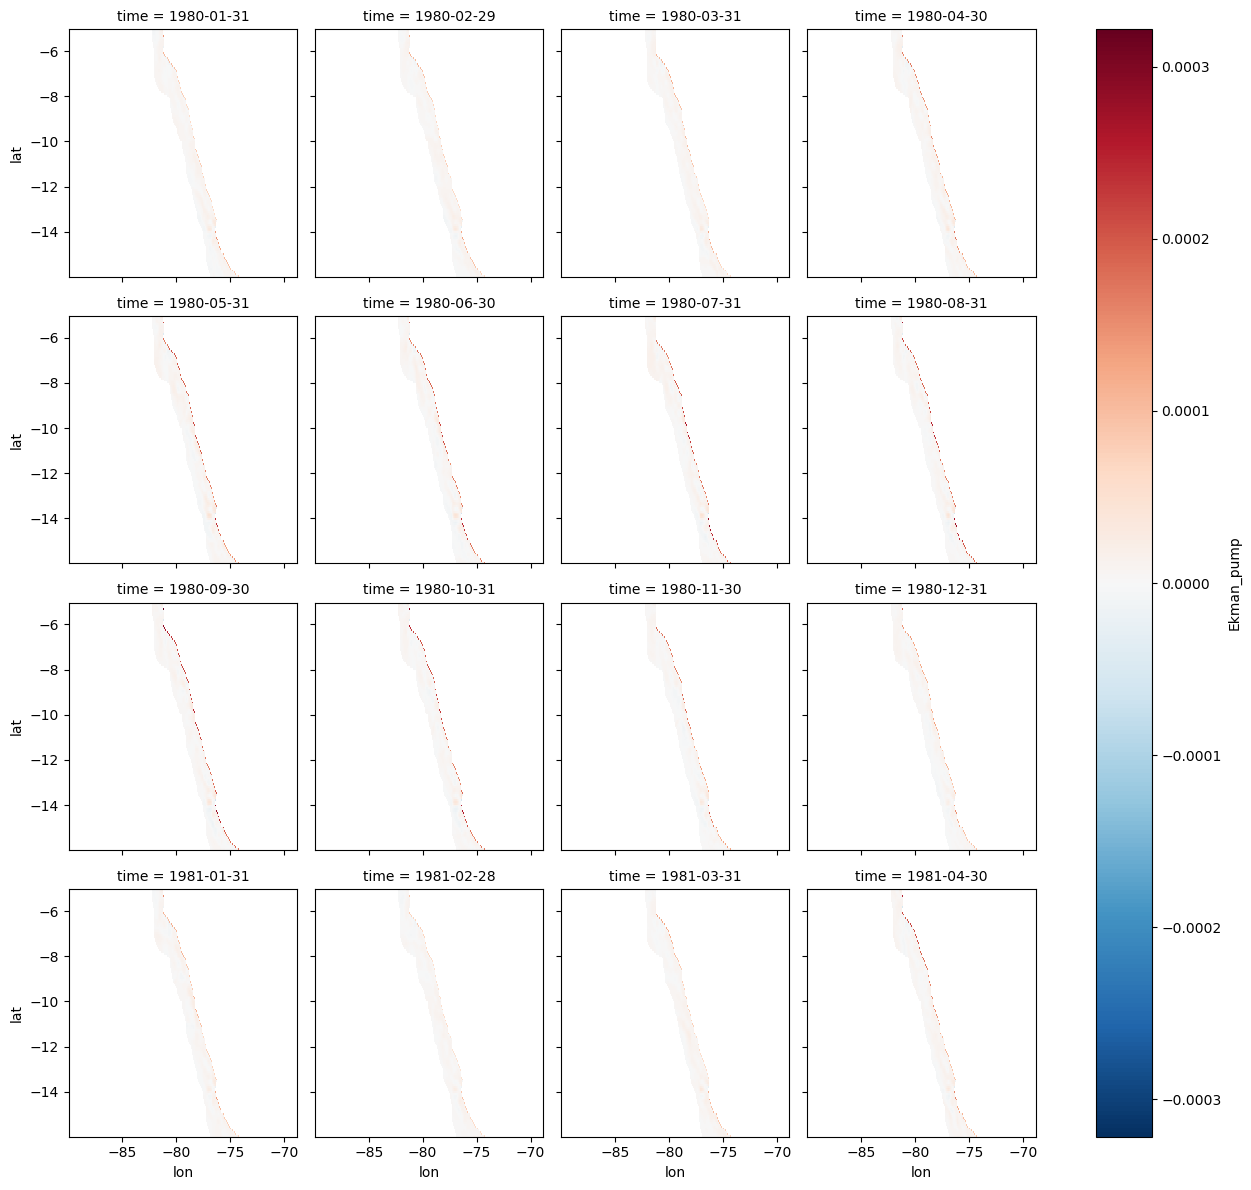

In [16]:
EK_pump.isel(time=slice(None, 16)).plot(
    x='lon', y='lat',  # Plot longitude on x-axis and latitude on y-axis
    col='time',        # Create subplots for each time step
    col_wrap=4         # Wrap subplots into 4 columns
)

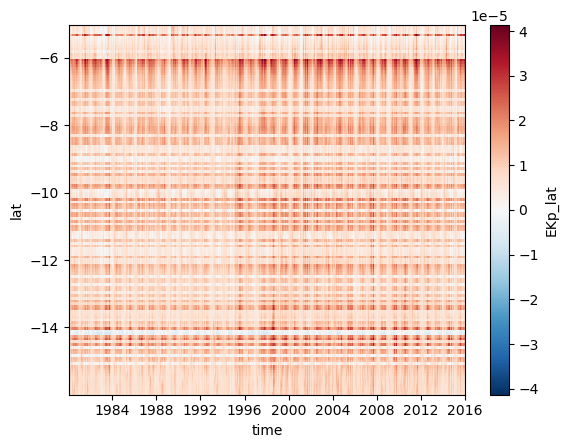

In [17]:
EK_ds['EKt_lat']=EK_ds['Ekman_transport'].mean(dim='lon', skipna=True)
EK_ds['EKp_lat']=EK_ds['Ekman_pump'].mean(dim='lon', skipna=True)

EK_ds['EKp_lat'].dropna(dim='lat').plot(y='lat')

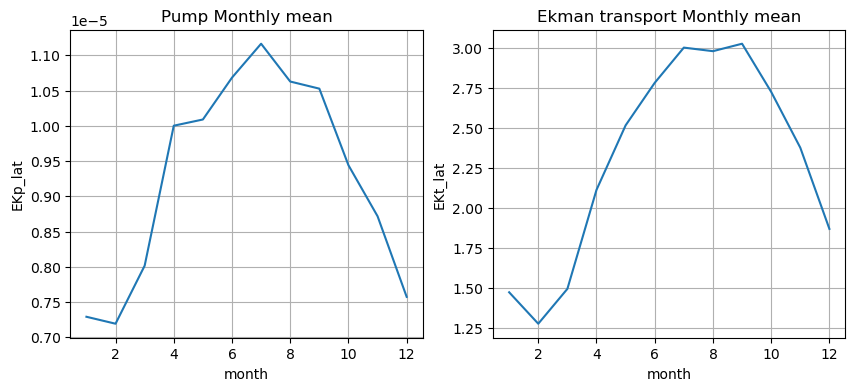

In [18]:
#----- Ekman pump
Pump_mmean = EK_ds['EKp_lat'].mean(dim='lat',skipna=True).groupby('time.month').mean(dim='time')
Pump_anomaly = EK_ds['EKp_lat'].mean(dim='lat', skipna=True).groupby('time.month') - Pump_mmean
#---- Ekman transport 
Ekt_mmean = EK_ds['EKt_lat'].mean(dim='lat',skipna=True).groupby('time.month').mean(dim='time')
Ekt_anomaly = EK_ds['EKt_lat'].mean(dim='lat', skipna=True).groupby('time.month') - Ekt_mmean

fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(10,4))

Pump_mmean.plot(ax=axes[0])
axes[0].set_title('Pump Monthly mean')
axes[0].grid(True)


Ekt_mmean.plot(ax=axes[1])
axes[1].set_title('Ekman transport Monthly mean')
axes[1].grid(True)

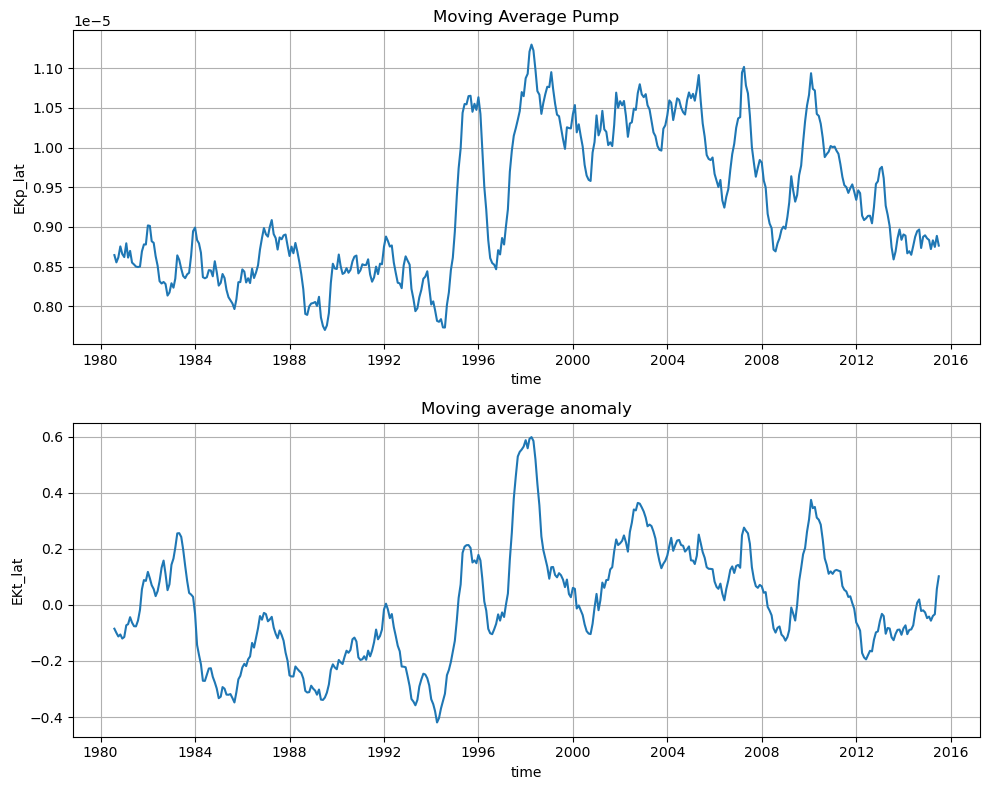

In [19]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10,8))

EK_ds['EKp_lat'].mean(dim='lat',skipna=True).rolling(time=13,center=True).mean().plot(ax=axes[0])
axes[0].set_title('Moving Average Pump')
axes[0].grid(True)

Ekt_anomaly.rolling(time=13,center=True).mean().plot(ax=axes[1])
axes[1].set_title('Moving average anomaly')
axes[1].grid(True)

plt.tight_layout()
plt.show()

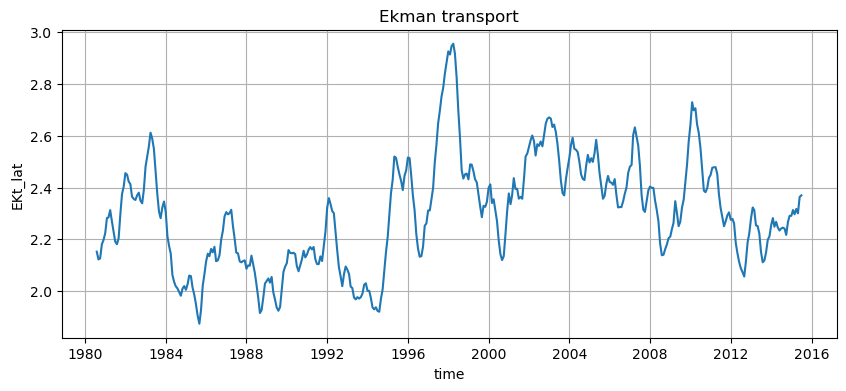

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,4))

EK_ds['EKt_lat'].mean(dim='lat',skipna=True).rolling(time=13,center=True).mean().plot(ax=ax)
ax.set_title('Ekman transport')
ax.grid(True)

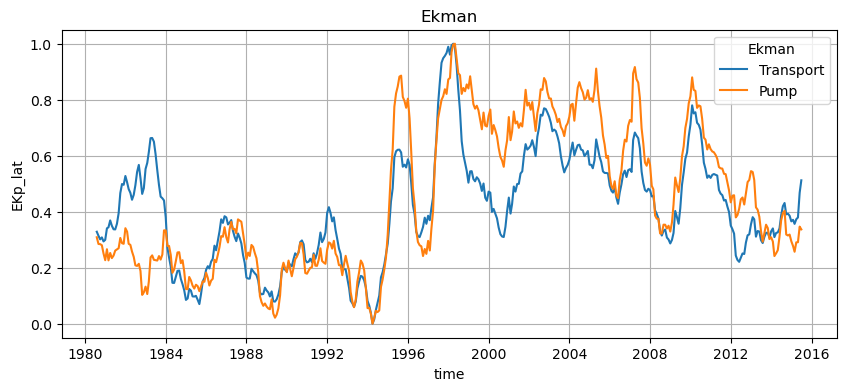

In [21]:
EKt_norm = normalize(Ekt_anomaly.rolling(time=13,center=True).mean())
Pump_norm = normalize(Pump_anomaly.rolling(time=13,center=True).mean())
# Pump_anomaly
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,4))
EKt_norm.plot(ax=ax, label='Transport')
Pump_norm.plot(ax=ax, label='Pump')
ax.set_title('Ekman')
ax.grid(True)
ax.legend(title='Ekman', bbox_to_anchor=(1, 1))

### AV

In [22]:
AV_data = loadmat("../../NHCS/Processed/AV.mat")
print(AV_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'LAT', 'LON', 'W_amean', 'W_analytical', 'mask'])


In [23]:
Coastal_up = loadmat("../../NHCS/Processed/Coastal_upwelling.mat")

In [24]:
AV_data['W_analytical'].shape

(602, 542, 432)

In [25]:
AV_ds = xr.Dataset(
    data_vars={
        'AV': (("time", "lat","lon"), AV_data['W_analytical'].transpose(2, 1, 0)),
        'CUpwelling':(('time','lat','lon'),Coastal_up['WcMean'].transpose(2, 1, 0))
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

AV_ds

<xarray.Dataset> Size: 2GB
Dimensions:     (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon         (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat         (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.869 9.951 10.03
  * time        (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    AV          (time, lat, lon) float64 1GB 3.175e-07 4.708e-07 ... nan nan
    CUpwelling  (time, lat, lon) float64 1GB 2.64e-128 2.551e-128 ... nan nan

In [26]:
AV_ds['AV'] = AV_ds['AV'] * inshore_mask
AV_cut = AV_ds['AV'].where((AV_ds.lat >= -16) & (AV_ds.lat <= -5) & 
                  (AV_ds.lon >= -90) & (AV_ds.lon <= -65), drop=True)

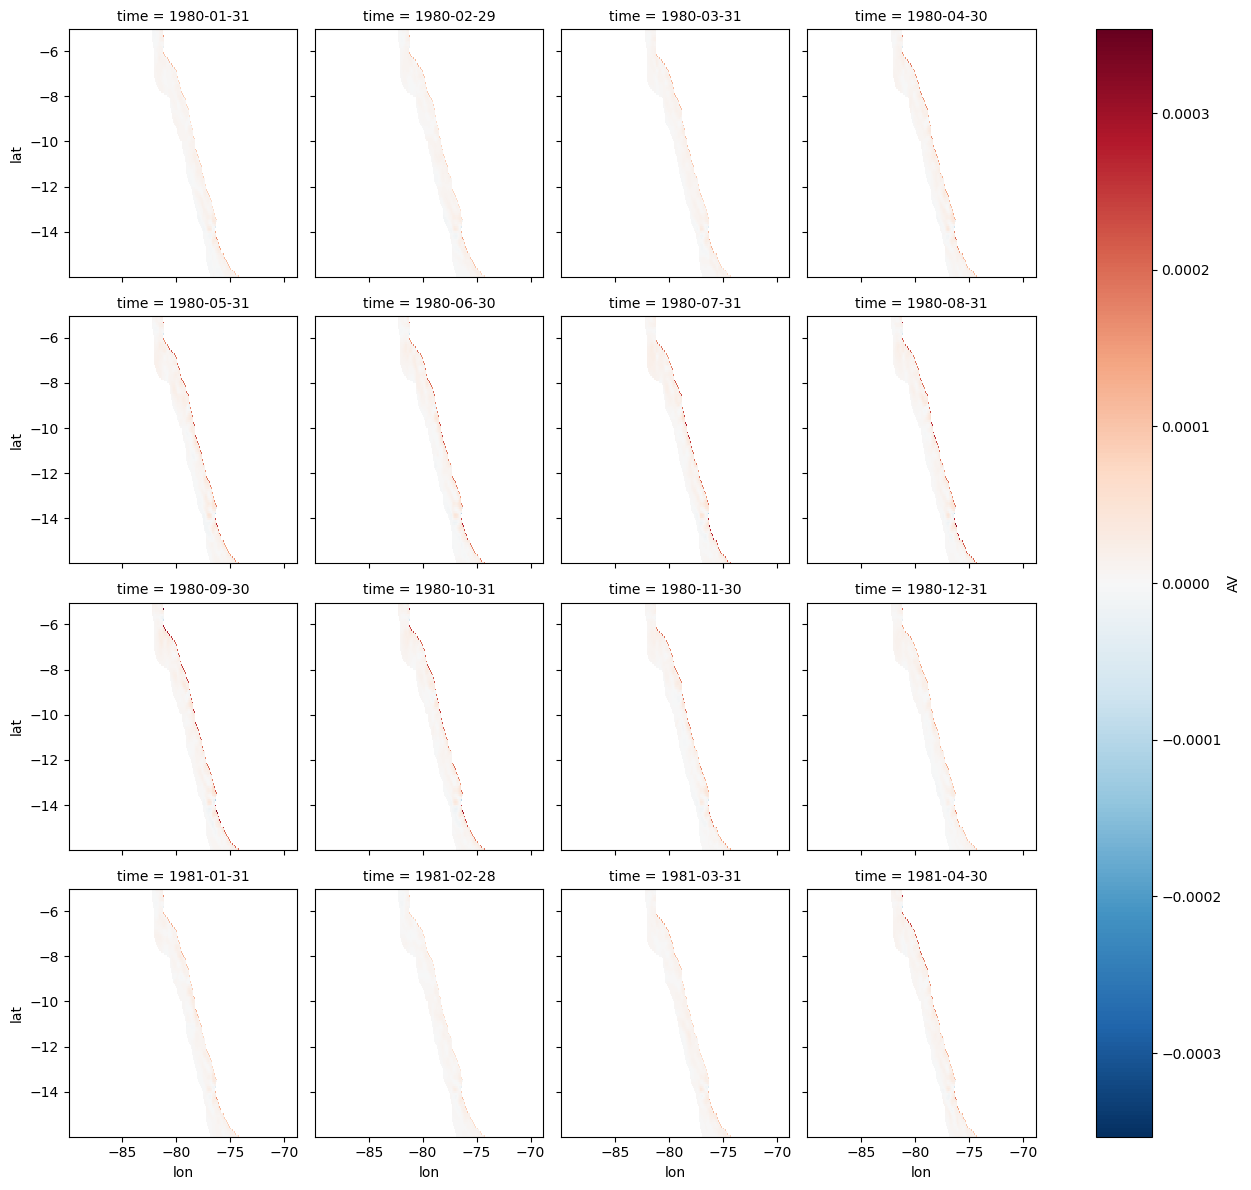

In [27]:
AV_cut.isel(time=slice(None, 16)).plot(
    x='lon', y='lat',  # Plot longitude on x-axis and latitude on y-axis
    col='time',        # Create subplots for each time step
    col_wrap=4         # Wrap subplots into 4 columns
)

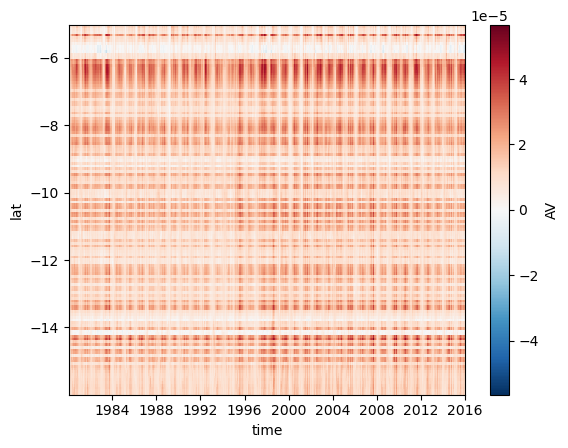

In [28]:
AV_ds['AV']=AV_cut.mean(dim='lon', skipna=True)

AV_ds['AV'].dropna(dim='lat').plot(y='lat')

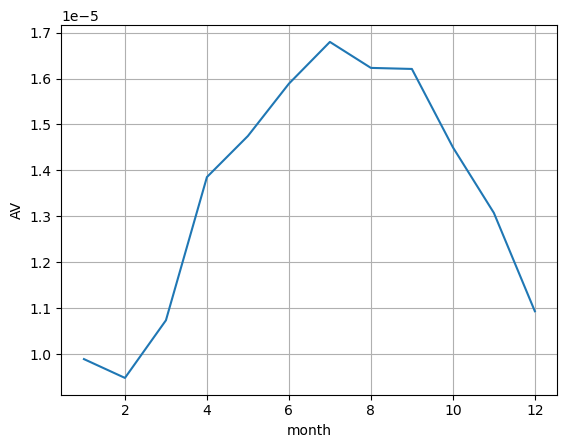

In [29]:
#----- Analytical velocity
AV_mmean = AV_ds['AV'].mean(dim='lat',skipna=True).groupby('time.month').mean(dim='time')
AV_anomaly = AV_ds['AV'].mean(dim='lat', skipna=True).groupby('time.month') - AV_mmean

AV_mmean.plot()
plt.grid(True)

### HUI upwelling index

In [30]:
HUI_data = loadmat("../../NHCS/Processed/HUI_index.mat")
print(HUI_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'HUI', 'lati', 'Mean_HUI', 'HUI_index', 'HUI_lat'])


In [31]:
HUI_data['HUI'].shape

(602, 542, 432)

In [32]:
HUI_ds = xr.Dataset(
    data_vars={
        'HUI': (("time", "lat","lon"), HUI_data['HUI'].transpose(2, 1, 0)),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

HUI_ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    HUI      (time, lat, lon) float64 1GB 1.077e-06 1.266e-06 ... nan nan

In [33]:
HUI_ds['HUI'] = HUI_ds['HUI'] * inshore_mask
HUI_cut = HUI_ds['HUI'].where((HUI_ds.lat >= -16) & (HUI_ds.lat <= -5) & 
                  (HUI_ds.lon >= -90) & (HUI_ds.lon <= -65), drop=True)

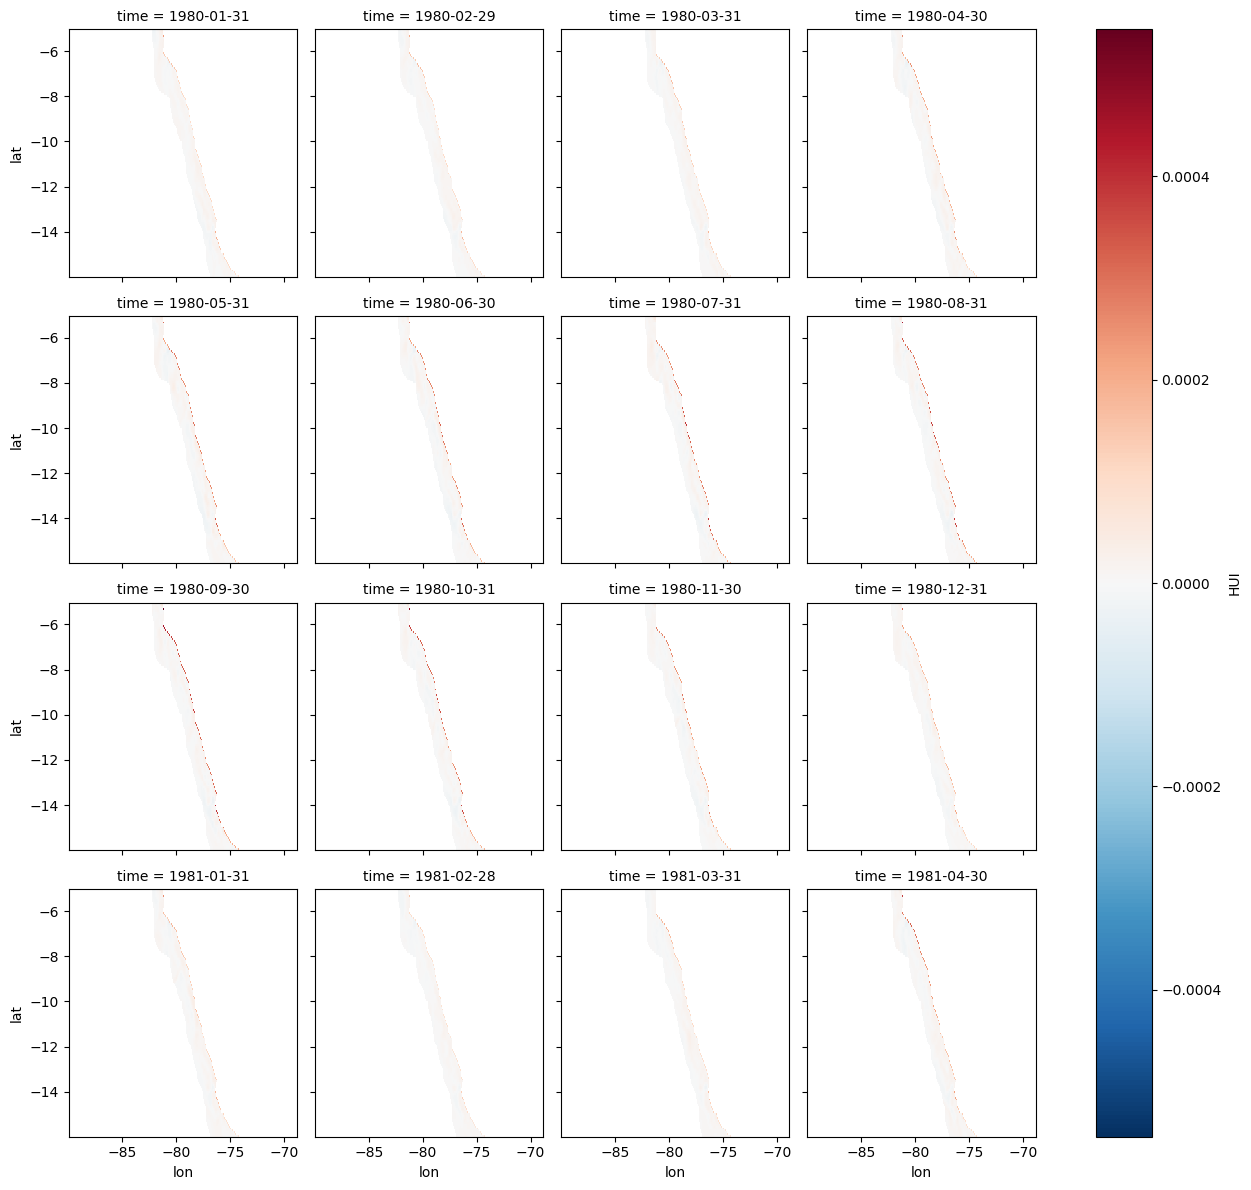

In [34]:
HUI_cut.isel(time=slice(None, 16)).plot(
    x='lon', y='lat',  # Plot longitude on x-axis and latitude on y-axis
    col='time',        # Create subplots for each time step
    col_wrap=4         # Wrap subplots into 4 columns
)

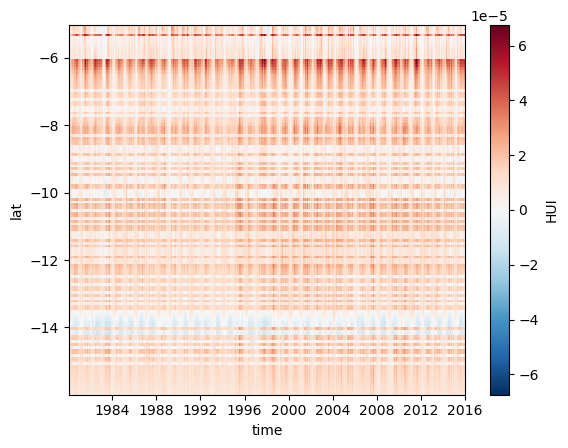

In [35]:
HUI_ds['HUI']=HUI_cut.mean(dim='lon', skipna=True)

HUI_ds['HUI'].dropna(dim='lat').plot(y='lat')

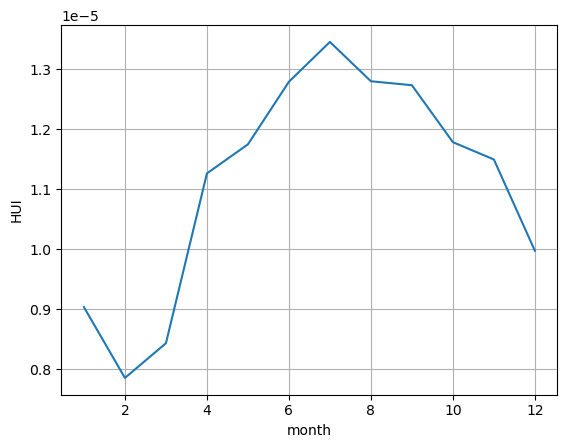

In [36]:
#----- HUI
HUI_mmean = HUI_ds['HUI'].mean(dim='lat',skipna=True).groupby('time.month').mean(dim='time')
HUI_anomaly = HUI_ds['HUI'].mean(dim='lat', skipna=True).groupby('time.month') - HUI_mmean

HUI_mmean.plot()
plt.grid(True)

### CUTI

In [37]:
#Coastal_upwelling
CUTI_data = loadmat("../../NHCS/Processed/CUTI.mat")
print(CUTI_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'CUTI', 'CUTI_latitudinal', 'Mean_CUTI', 'latCUTI'])


In [38]:
CUTI_data['CUTI'].shape

(602, 542, 432)

In [39]:
CUTI_ds = xr.Dataset(
    data_vars={
        'CUTI': (("time", "lat","lon"), CUTI_data['CUTI'].transpose(2, 1, 0)),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

CUTI_ds

<xarray.Dataset> Size: 564MB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    CUTI     (time, lat, lon) float32 564MB 0.09788 0.102 0.1076 ... nan nan nan

In [40]:
CUTI_ds['CUTI'] = CUTI_ds['CUTI'] * inshore_mask
CUTI_cut = CUTI_ds['CUTI'].where((CUTI_ds.lat >= -16) & (CUTI_ds.lat <= -5) & 
                  (CUTI_ds.lon >= -90) & (CUTI_ds.lon <= -65), drop=True)

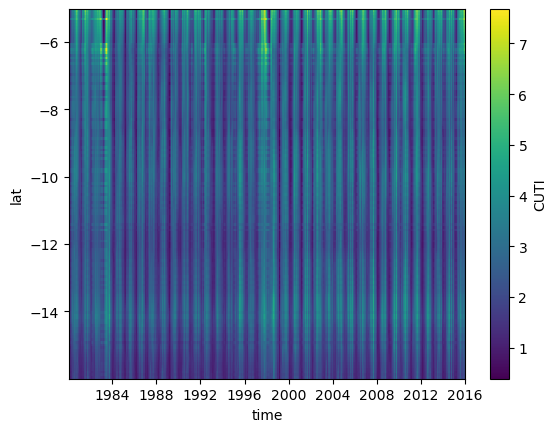

In [41]:
CUTI_ds['CUTI']=CUTI_cut.mean(dim='lon', skipna=True)*-1

CUTI_ds['CUTI'].dropna(dim='lat').plot(y='lat')

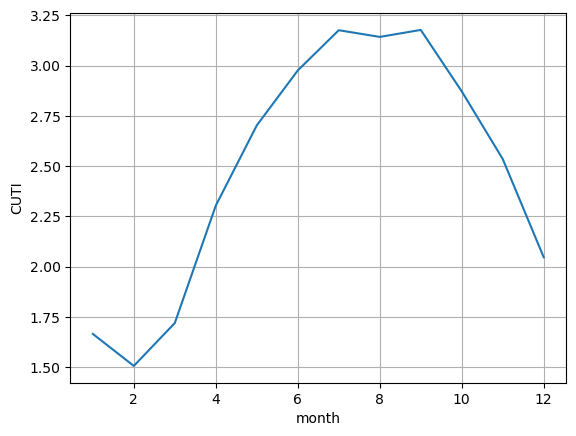

In [42]:
#----- CUTI
CUTI_mmean = CUTI_ds['CUTI'].mean(dim='lat',skipna=True).groupby('time.month').mean(dim='time')
CUTI_anomaly = CUTI_ds['CUTI'].mean(dim='lat', skipna=True).groupby('time.month') - CUTI_mmean

CUTI_mmean.plot()
plt.grid(True)

### BEUTI

In [43]:
#Coastal_upwelling
BEUTI_data = loadmat("../../NHCS/Processed/BEUTI.mat")
print(BEUTI_data.keys())

BEUTI_ds = xr.Dataset(
    data_vars={
        'BEUTI': (("time", "lat","lon"), BEUTI_data['BEUTI'].transpose(2, 1, 0)),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

BEUTI_ds

dict_keys(['__header__', '__version__', '__globals__', 'BEUTI', 'Mean_BEUTI', 'latCUTI', 'BEUTI_latitudinal'])


<xarray.Dataset> Size: 564MB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    BEUTI    (time, lat, lon) float32 564MB 0.01551 0.0162 0.01768 ... nan nan

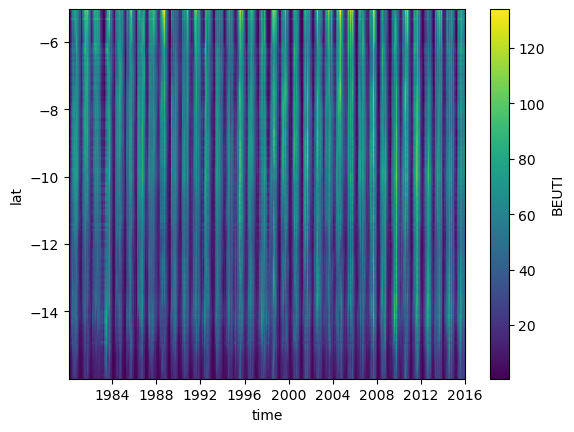

In [44]:
BEUTI_ds['BEUTI'] = BEUTI_ds['BEUTI'] * inshore_mask
BEUTI_cut = BEUTI_ds['BEUTI'].where((BEUTI_ds.lat >= -16) & (BEUTI_ds.lat <= -5) & 
                  (BEUTI_ds.lon >= -90) & (BEUTI_ds.lon <= -65), drop=True)

BEUTI_ds['BEUTI']=BEUTI_cut.mean(dim='lon', skipna=True)*-1

BEUTI_ds['BEUTI'].dropna(dim='lat').plot(y='lat')

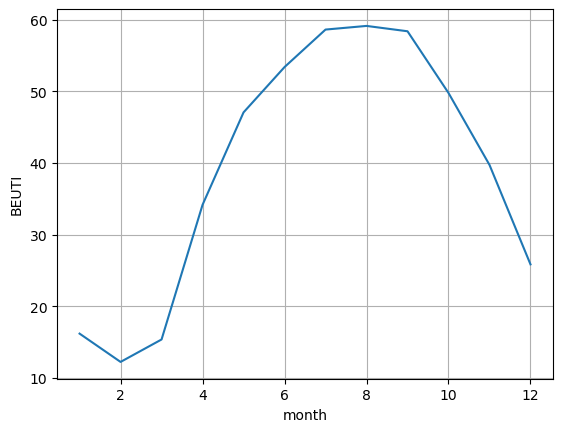

In [45]:
#----- BEUTI
BEUTI_mmean = BEUTI_ds['BEUTI'].mean(dim='lat',skipna=True).groupby('time.month').mean(dim='time')
BEUTI_anomaly = BEUTI_ds['BEUTI'].mean(dim='lat', skipna=True).groupby('time.month') - BEUTI_mmean

BEUTI_mmean.plot()
plt.grid(True)

### BUI

In [46]:
#Coastal_upwelling
BUI_data = loadmat("../../NHCS/Processed/BUI.mat")
print(BUI_data.keys())

BUI_ds = xr.Dataset(
    data_vars={
        'BUI': (("time", "lat","lon"), BUI_data['BUI'].transpose(2, 1, 0)),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

BUI_ds

dict_keys(['__header__', '__version__', '__globals__', 'BUI', 'LAT', 'LON', 'UE', 'mask'])


<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    BUI      (time, lat, lon) float64 1GB -0.03709 -0.03867 -0.04079 ... nan nan

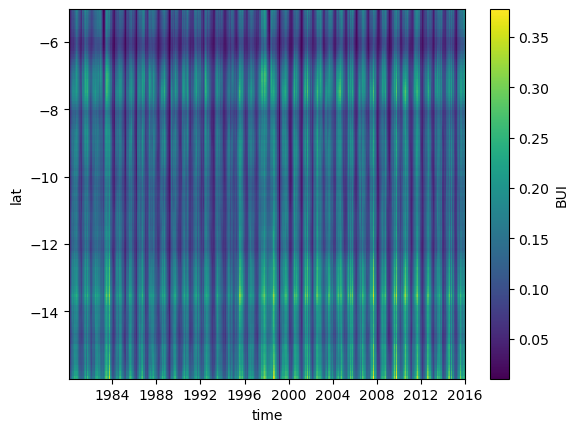

In [47]:
BUI_ds['BUI'] = BUI_ds['BUI'] * inshore_mask
BUI_cut = BUI_ds['BUI'].where((BUI_ds.lat >= -16) & (BUI_ds.lat <= -5) & 
                  (BUI_ds.lon >= -90) & (BUI_ds.lon <= -65), drop=True)

BUI_ds['BUI']=BUI_cut.mean(dim='lon', skipna=True)

BUI_ds['BUI'].dropna(dim='lat').plot(y='lat')

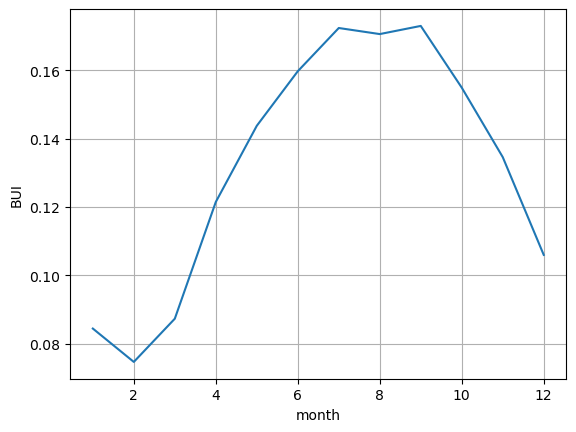

In [48]:
#----- BUI
BUI_mmean = BUI_ds['BUI'].mean(dim='lat',skipna=True).groupby('time.month').mean(dim='time')
BUI_anomaly = BUI_ds['BUI'].mean(dim='lat', skipna=True).groupby('time.month') - BUI_mmean

BUI_mmean.plot()
plt.grid(True)

### W at the MLD

In [49]:
#Coastal_upwelling
WMLD_data = loadmat("../../NHCS/Processed/WMLD_MLD.mat")
print(WMLD_data.keys())

WMLD_ds_ = xr.Dataset(
    data_vars={
        'WMLD': (("time", "lat","lon"), WMLD_data['WMLD'].transpose(2, 0, 1)),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

WMLD_ds_

##------- Calculated MLD ------------ #
WMLD_dat = loadmat("../../NHCS/Processed/WMLD_MLD_cal.mat")
print(WMLD_dat.keys())

WMLD_cal = xr.Dataset(
    data_vars={
        'WMLD': (("time", "lat","lon"), WMLD_dat['WMLD'].transpose(2, 1, 0)),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

# print(WMLD_ds)
print(WMLD_cal)


dict_keys(['__header__', '__version__', '__globals__', 'MLD', 'WMLD'])
dict_keys(['__header__', '__version__', '__globals__', 'MLD', 'WMLD'])
<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    WMLD     (time, lat, lon) float64 1GB 4.613e-08 4.613e-08 ... nan nan


/tmp/ipykernel_924309/3192447463.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


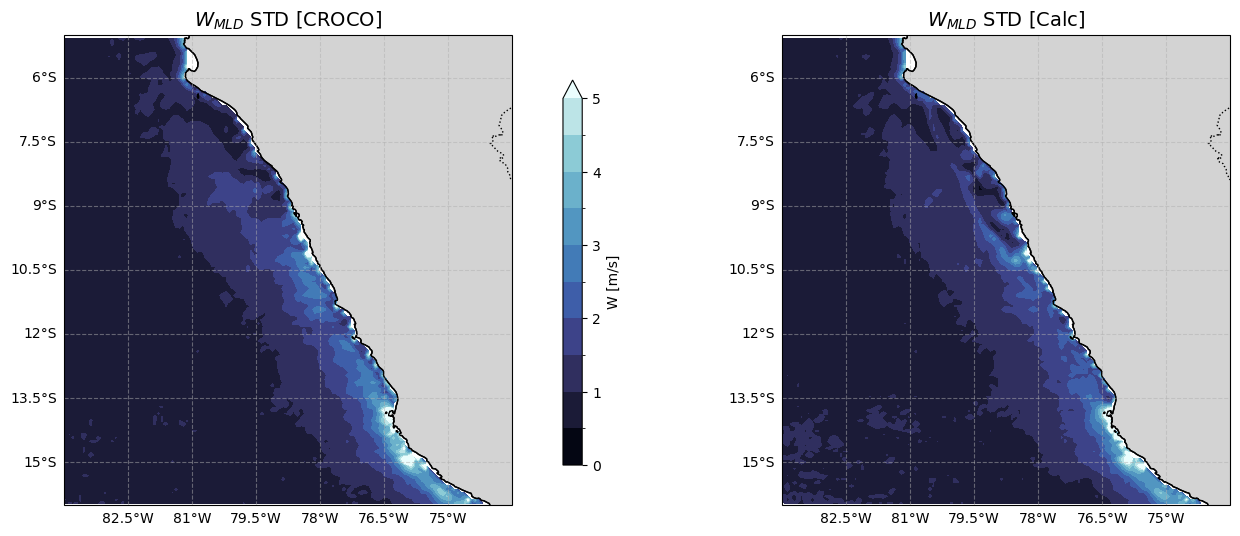

In [50]:
mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)

std_Croco = WMLD_ds_.std(dim='time')*86400*mask_nan 

std_Calc = WMLD_cal.std(dim='time')*86400

fig, ax = plt.subplots(ncols=2, nrows=1, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(14, 5))

# Plot the first subplot (CROCO data)
cf1 = std_Croco.WMLD.sel(lon=slice(-84, -73.5), lat=slice(-16, -5)).plot.contourf(
    ax=ax[0],  # Plot on the first subplot
    transform=ccrs.PlateCarree(),  # Specify the transform for the data
    vmin=0, vmax=5,
    cmap=cm.ice,
    levels=np.arange(0, 5 + 0.5, 0.5),
    add_colorbar=False  # Disable the automatic colorbar
)

# Add map features to the first subplot
ax[0].add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgrey')
ax[0].add_feature(cfeature.COASTLINE)
ax[0].add_feature(cfeature.BORDERS, linestyle=':')

# Set the title for the first subplot
ax[0].set_title('$W_{MLD}$ STD [CROCO]', fontsize=14)

# Add gridlines and labels to the first subplot
gl1 = ax[0].gridlines(draw_labels=True, linestyle='--', alpha=0.5, crs=ccrs.PlateCarree())
gl1.top_labels = False  # Disable top labels
gl1.right_labels = False  # Disable right labels

# Plot the second subplot (Calc data)
cf2 = std_Calc.WMLD.sel(lon=slice(-84, -73.5), lat=slice(-16, -5)).plot.contourf(
    ax=ax[1],  # Plot on the second subplot
    transform=ccrs.PlateCarree(),  # Specify the transform for the data
    vmin=0, vmax=5,
    cmap=cm.ice,
    levels=np.arange(0, 5 + 0.5, 0.5),
    add_colorbar=False  # Disable the automatic colorbar
)

# Add map features to the second subplot
ax[1].add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgrey')
ax[1].add_feature(cfeature.COASTLINE)
ax[1].add_feature(cfeature.BORDERS, linestyle=':')

# Set the title for the second subplot
ax[1].set_title('$W_{MLD}$ STD [Calc]', fontsize=14)

# Add gridlines and labels to the second subplot
gl2 = ax[1].gridlines(draw_labels=True, linestyle='--', alpha=0.5, crs=ccrs.PlateCarree())
gl2.top_labels = False  # Disable top labels
gl2.right_labels = False  # Disable right labels

# Add a single colorbar for both subplots
cbar = plt.colorbar(cf1, orientation='vertical', pad=0.02, fraction=0.5, ax=ax)
cbar.set_label('W [m/s]')

# Set the extent for both subplots
for a in ax:
    a.set_extent([-84, -73.5, -16, -5], crs=ccrs.PlateCarree())

# Adjust layout and show the plot
# plt.savefig('Figures/W_STD'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')

plt.tight_layout()
plt.show()

In [51]:
mean_WMLD = WMLD_ds_.WMLD.sel(lat=slice(-16, -5), lon=slice(-84, -73.5)).mean(dim='time',skipna=True)
mean_WMLD = xr.where(mean_WMLD == 0, np.nan, mean_WMLD)

mean_WMLD_cal = WMLD_cal.WMLD.sel(lat=slice(-16, -5), lon=slice(-84, -73.5)).mean(dim='time',skipna=True)
mean_WMLD_cal = xr.where(mean_WMLD_cal == 0, np.nan, mean_WMLD)

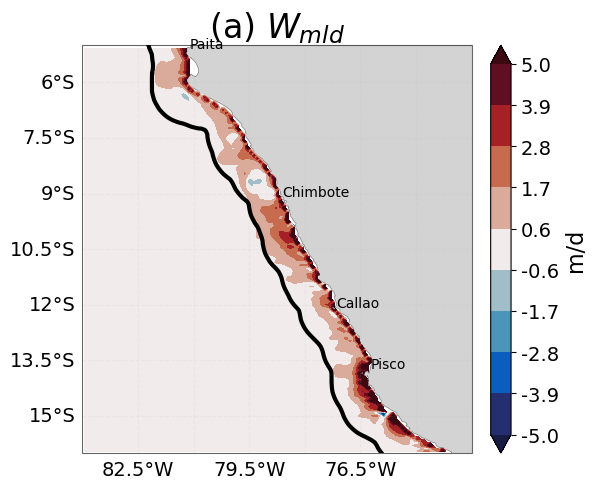

In [52]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm 


# Extract latitude and longitude
lat = mean_WMLD.lat.values
lon = mean_WMLD.lon.values

# fig, ax = plt.subplots(ncols=2, nrows=1, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(14, 5))
# Create a meshgrid for longitude and latitude
loni, lati = np.meshgrid(lon, lat)
levels = np.linspace(-5, 5, 10)  # From -5 to 5 in steps of 1
vmin, vmax = levels.min(), levels.max()

norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# Create a figure and axis with a cartopy projection
fig, ax = plt.subplots(ncols=1, nrows=1, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 5))
# Plot the data using contourf
cs=plt.contourf(loni, lati, mean_WMLD*86400, cmap=cm.balance,norm=norm, extend='both',
                levels=levels)

for key in Puertos:
  x,y = Puertos[key][1],Puertos[key][0]
  plt.text(x,y,key,fontsize=10)
    
# ax.clim(-2,2)
# Add a colorbar
cbar = plt.colorbar(cs, orientation='vertical', pad=0.02, fraction=0.1)
cbar.set_label('m/d',fontsize=16)

# Add land feature with grey filler color
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='lightgray',  # Set the land fill color to grey
    edgecolor=None  # Set the coastline color to black
)

ax.add_feature(land, alpha=1)

ax.add_feature(cfeature.LAND, edgecolor='grey')

ax.set_title('(a) $W_{mld}$', fontsize=24)

gl2 = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.1, crs=ccrs.PlateCarree())
gl2.top_labels = False  # Disable top labels
gl2.right_labels = False  # Disable right labels

gl2.xlabel_style = {'size': 14}
gl2.ylabel_style = {'size': 14}

# Set extent to focus on the region of interest
ax.set_extent([-84, -73.5, -16, -5], crs=ccrs.PlateCarree())
plt.plot(lonb1,latb1,color='black',linewidth=3)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('black')  # Light gray color
    spine.set_alpha(0.6)      
    

# plt.savefig('Figures/W_MLD_LTM_paper'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
# Show the plot

cbar.set_ticklabels([f"{tick:.1f}" for tick in levels],fontsize=14)  # Round to 1 decimal
plt.tight_layout()
plt.show()


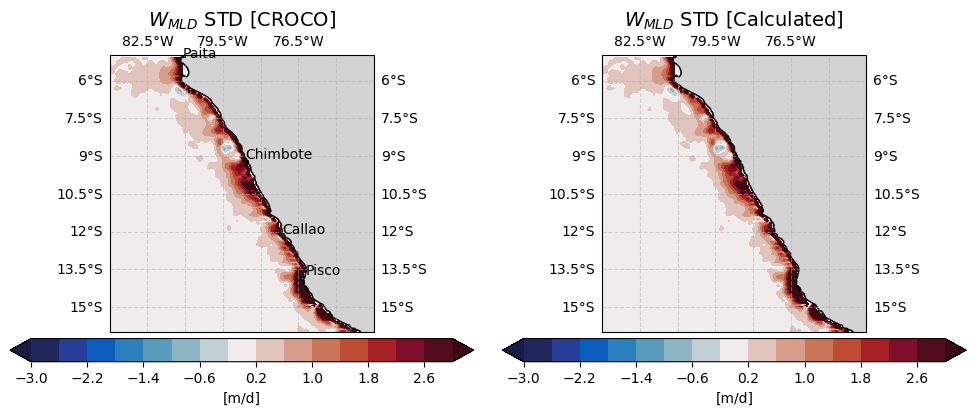

In [53]:

norm = TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)
# Create a figure and axis with a cartopy projection
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(10,4), subplot_kw=dict(projection=ccrs.PlateCarree()))


# Plot the data using contourf
cs=ax[0].contourf(loni, lati, mean_WMLD*86400, cmap=cm.balance,norm=norm, extend='both',
                levels=np.arange(-3, 3+0.4, 0.4))

for key in Puertos:
  x,y = Puertos[key][1],Puertos[key][0]
  ax[0].text(x,y,key,fontsize=10)
    
# ax.clim(-2,2)
# Add a colorbar
cbar = plt.colorbar(cs, orientation='horizontal', pad=0.02, fraction=0.1,ax=ax[0])
cbar.set_label('[m/d]')

# Add land feature with grey filler color
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='lightgrey',  # Set the land fill color to grey
    edgecolor='black'  # Set the coastline color to black
)

# Add map features
ax[0].add_feature(land)
# ax.add_feature(cfeature.COASTLINE,facecolor='grey')
ax[0].add_feature(cfeature.LAND, edgecolor='black')
# ax.add_feature(cfeature.OCEAN)

# Add gridlines and labels
ax[0].gridlines(draw_labels=True, linestyle='--', alpha=0.5)
ax[0].set_title('W at MLD', fontsize=14)

# Set extent to focus on the region of interest
ax[0].set_extent([-84, -73.5, -16, -5], crs=ccrs.PlateCarree())

# ax.coastlines(resolution='10km')
# plt.savefig('Figures/W_MLD_LTM'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
# Show the plot

##---- Wcalculated

# Plot the data using contourf
cs=ax[1].contourf(loni, lati, mean_WMLD_cal*86400, cmap=cm.balance,norm=norm, extend='both',
                levels=np.arange(-3, 3+0.4, 0.4))

# for key in Puertos:
#   x,y = Puertos[key][1],Puertos[key][1]
#   ax[1].text(x,y,key,fontsize=10)
    
# ax.clim(-2,2)
# Add a colorbar
cbar = plt.colorbar(cs, orientation='horizontal', pad=0.02, fraction=0.1,ax=ax[1])
cbar.set_label('[m/d]')

# Add land feature with grey filler color
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='lightgrey',  # Set the land fill color to grey
    edgecolor='black'  # Set the coastline color to black
)

# Add map features
ax[1].add_feature(land)
# ax.add_feature(cfeature.COASTLINE,facecolor='grey')
ax[1].add_feature(cfeature.LAND, edgecolor='black')
# ax.add_feature(cfeature.OCEAN)

# Add gridlines and labels
ax[1].gridlines(draw_labels=True, linestyle='--', alpha=0.5)
ax[1].set_title('W at MLD', fontsize=14)

# Set extent to focus on the region of interest
ax[1].set_extent([-84, -73.5, -16, -5], crs=ccrs.PlateCarree())

ax[0].set_title('$W_{MLD}$ STD [CROCO]', fontsize=14)
ax[1].set_title('$W_{MLD}$ STD [Calculated]', fontsize=14)
# ax.coastlines(resolution='10km')
# plt.savefig('Figures/Calc_W_MLD_LTM'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
# Show the plot
plt.tight_layout()
plt.show()


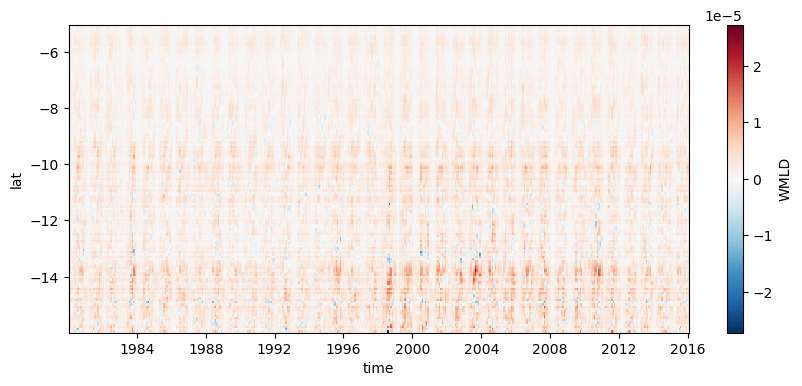

In [54]:
WMLD_ds_['WMLD'] = WMLD_ds_['WMLD'] * inshore_mask
WMLD_cut = WMLD_ds_['WMLD'].where((WMLD_ds_.lat >= -16) & (WMLD_ds_.lat <= -5) & 
                  (WMLD_ds_.lon >= -90) & (WMLD_ds_.lon <= -65), drop=True)

WMLD_ds_['WMLD']=WMLD_cut.mean(dim='lon', skipna=True)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,4))
WMLD_ds_['WMLD'].dropna(dim='lat').plot(ax=ax,y='lat')

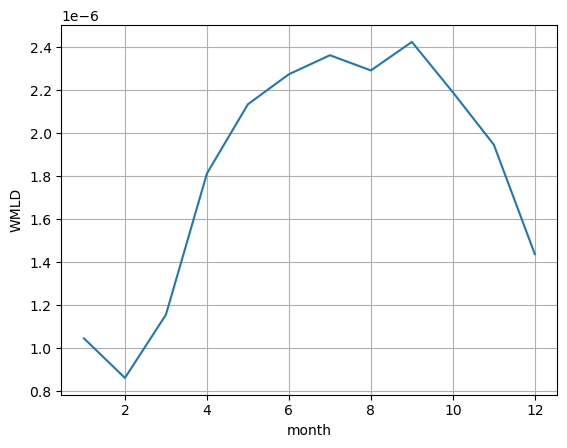

In [55]:
#---- WMLD
WMLD_mmean = WMLD_ds_['WMLD'].mean(dim='lat',skipna=True).groupby('time.month').mean(dim='time')
WMLD_anomaly = WMLD_ds_['WMLD'].mean(dim='lat', skipna=True).groupby('time.month') - WMLD_mmean

WMLD_mmean.plot()
plt.grid(True)

/tmp/ipykernel_924309/601135501.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels,fontsize=16)


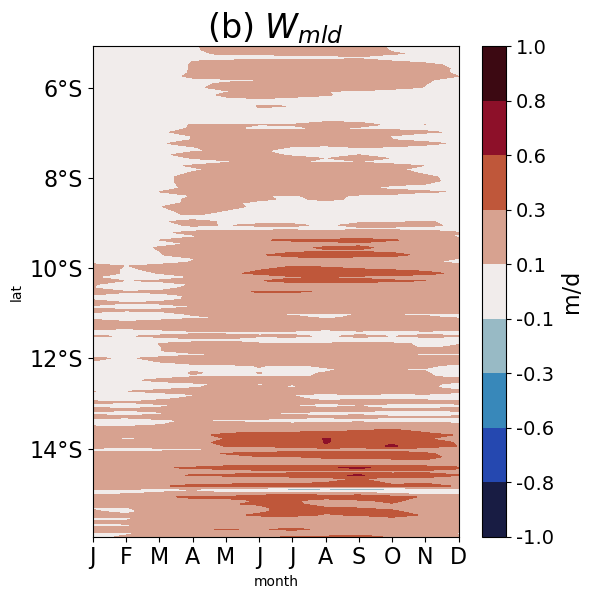

In [56]:
wmld_hv=WMLD_ds_['WMLD'].sel(lat=slice(-16,-5)).groupby('time.month').mean(dim='time')*60*60*24

fig, ax = plt.subplots(figsize=(6,6))

# np.linspace(-5, 5, 10) 
vmin=-1; vmax=1
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

levels=np.linspace(vmin,vmax,10)

cf=wmld_hv.plot.contourf(x='month',vmin=vmin, vmax=vmax,cmap = cm.balance,
                                                                 norm=norm,levels=levels,add_colorbar=False)
ax = plt.gca()
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label('m/d',fontsize=16)
cbar.ax.set_yticklabels([f"{tick:.1f}" for tick in levels], fontsize=14)  # 1 decimal formatting

yticks = ax.get_yticks()  # Get current y-tick positions

# Format labels with °S for negative values (Southern Hemisphere)
new_labels = [f"{-y:.0f}°S" if y < 0 else f"{y:.0f}°N" for y in yticks]
ax.set_yticklabels(new_labels,fontsize=16)

plt.title('(b) $W_{mld}$',fontsize=24)
plt.tight_layout()

months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
plt.xticks(range(1, 13), months,fontsize=16)  # Assuming your data has 12 points (one per month)

# plt.savefig('Figures/wmld_season_poster'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

Text(0, 0.5, 'Latitude')

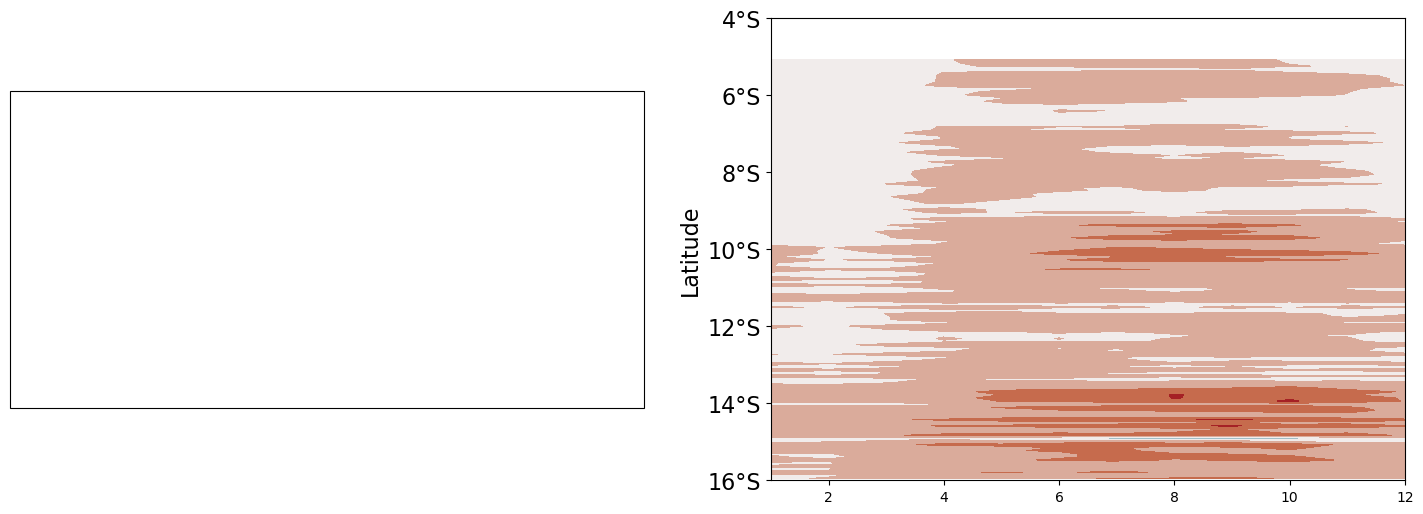

In [57]:
# Create figure with two subplots - ONLY first one needs projection
fig = plt.figure(figsize=(18, 6))
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())  # Map plot
ax2 = plt.subplot(122)  # Regular plot for Hovmöller

# [Keep all your existing plotting code for ax1]

# For the Hovmöller plot:
cf = ax2.contourf(range(1,13), wmld_hv.lat.values, wmld_hv.T,  # Transpose if needed
                 cmap=cm.balance, norm=norm, levels=levels)

# Explicitly set y-axis labels
ax2.set_yticks(yticks)
ax2.set_yticklabels(new_labels, fontsize=16)
ax2.set_ylabel('Latitude', fontsize=16)  # Add y-axis label if needed

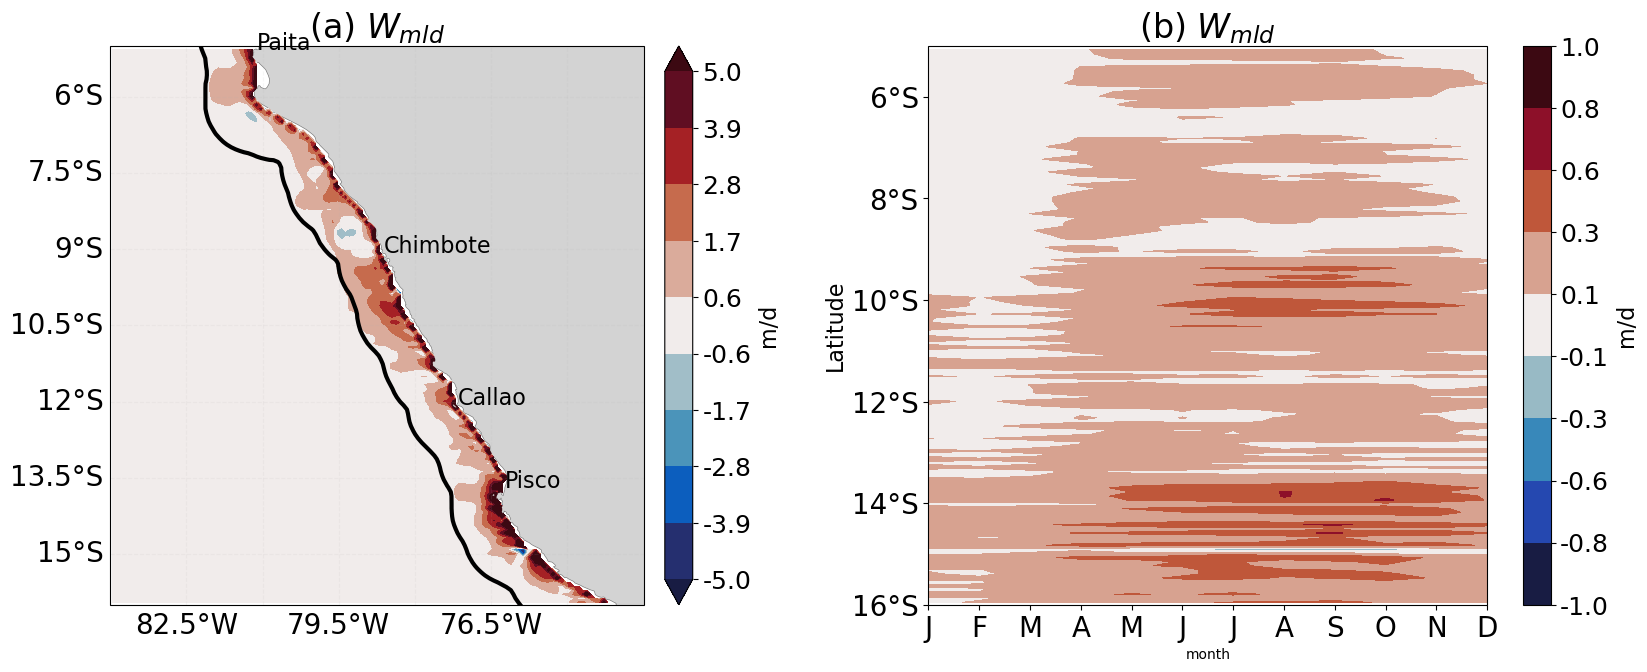

In [68]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import TwoSlopeNorm


# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18*1.1, 6*1.1), 
                              gridspec_kw={'width_ratios': [1.5, 1]},
                              subplot_kw={'projection': ccrs.PlateCarree()})

# First subplot (map)
# --------------------------------------------------------------------------
# Set up levels and normalization
levels = np.linspace(-5, 5, 10)
vmin, vmax = levels.min(), levels.max()
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# Plot the data using contourf
cs = ax1.contourf(loni, lati, mean_WMLD*86400, cmap=cm.balance, norm=norm, 
                 extend='both', levels=levels)

# Add port labels
for key in Puertos:
    x, y = Puertos[key][1], Puertos[key][0]
    ax1.text(x, y, key, fontsize=16)

# Add colorbar
cbar1 = plt.colorbar(cs, ax=ax1, orientation='vertical', pad=0.02, fraction=0.1)
cbar1.set_label('m/d', fontsize=16)
cbar1.set_ticklabels([f"{tick:.1f}" for tick in levels], fontsize=18)

# Add map features
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='lightgray',
    edgecolor=None
)
ax1.add_feature(land, alpha=1)
ax1.add_feature(cfeature.LAND, edgecolor='grey')
ax1.set_title('(a) $W_{mld}$', fontsize=24)

# Configure gridlines
gl = ax1.gridlines(draw_labels=True, linestyle='--', alpha=0.1)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 20}
gl.ylabel_style = {'size': 20}

# Set map extent
ax1.set_extent([-84, -73.5, -16, -5])
ax1.plot(lonb1, latb1, color='black', linewidth=3)

# Second subplot (seasonal cycle)
# --------------------------------------------------------------------------
# Set up levels and normalization
vmin, vmax = -1, 1
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
levels = np.linspace(vmin, vmax, 10)

# Plot the seasonal cycle
cf = wmld_hv.plot.contourf(ax=ax2, x='month', vmin=vmin, vmax=vmax, 
                          cmap=cm.balance, norm=norm, levels=levels, 
                          add_colorbar=False)

# Add colorbar
cbar2 = plt.colorbar(cf, ax=ax2)
cbar2.set_label('m/d', fontsize=16)
cbar2.ax.set_yticklabels([f"{tick:.1f}" for tick in levels], fontsize=18)

# Format y-axis labels
yticks = ax2.get_yticks()
new_labels = [f"{-y:.0f}°S" if y < 0 else f"{y:.0f}°N" for y in yticks]
ax2.set_yticks(yticks)
ax2.set_yticklabels(new_labels, fontsize=20)
ax2.set_ylabel('Latitude',fontsize=16)
ax2.set_ylim(-16,-5)

# Configure x-axis
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(months, fontsize=20)
ax2.set_title('(b) $W_{mld}$', fontsize=24)

# Adjust layout
plt.tight_layout()

# Save or show
# plt.savefig('Figures/paper/combined_WMLD_plots.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

## Latitudinal Mean

In [ ]:
WMLD_lat = WMLD_ds_['WMLD'] * inshore_mask
# WMLD_lat
CUI_ds

# fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,7))
# WMLD_lat.mean(dim='lon').sel(lat=slice(-20,0)).mean(dim='time').rolling(lat=13,center=True).mean().plot(ax=ax,y='lat')
# plt.grid()
# plt.ylim([-16, -5])

In [ ]:
# wmld_lat = WMLD_lat.mean(dim='lon').sel(lat=slice(-20,0)).mean(dim='time').rolling(lat=13,center=True).mean() 
wmld_lat = WMLD_lat.mean(dim='lon').sel(lat=slice(-20,0)) * 86400

w_mean_ = wmld_lat.mean(dim='time').rolling(lat=13,center=True).mean()  # Mean across time for each depth
w_std_ = wmld_lat.std(dim='time').rolling(lat=13,center=True).mean()    # Standard deviation across time for each depth


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

axes[0].plot(w_mean_, w_mean_['lat'], color='blue', label='Mean', linewidth=2)
axes[0].fill_betweenx(w_mean_['lat'], w_mean_ - w_std_, w_mean_ + w_std_, 
                  color='lightblue', alpha=0.5, label='±1 SD')
axes[0].set_title('W at MLD')
axes[0].grid(linestyle='--', alpha=0.5)
axes[0].set_xlabel('W [m/day]')
axes[0].set_ylabel('m')
axes[0].set_ylim([-16, -5])
# axes[0].axvline(0, color='black', linestyle='--', linewidth=1)

## Seasonality 

In [60]:
time = np.linspace(1,12,12)

UI_dic_real = {
    # 'time':time,
    'WMLD':WMLD_mmean.values,
    'AV':AV_mmean.values,
    'CUI':CUI_mmean.values,
    'Pump':Pump_mmean.values,
    'EkT':Ekt_mmean.values,
    # 'HUI':HUI_mmean.values,
    'CUTI':CUTI_mmean.values,
    'BEUTI':BEUTI_mmean.values,
    'BUI':BUI_mmean.values
}

season_mmonth = pd.DataFrame(UI_dic_real)
season_mmonth

,WMLD,AV,CUI,Pump,EkT,CUTI,BEUTI,BUI
0,1.046306e-06,0.000010,2.132665,0.000007,1.470560,1.665778,16.158996,0.084405
1,8.623523e-07,0.000009,2.536556,0.000007,1.273963,1.506551,12.204762,0.074641
2,1.156308e-06,0.000011,3.135864,0.000008,1.491909,1.719886,15.340343,0.087287
3,1.812565e-06,0.000014,4.375791,0.000010,2.110769,2.303925,34.156875,0.121443
4,2.134386e-06,0.000015,4.203512,0.000010,2.514221,2.702565,47.072026,0.143724
5,2.273937e-06,0.000016,3.297929,0.000011,2.780212,2.975765,53.405240,0.159685
6,2.362218e-06,0.000017,2.504006,0.000011,3.000328,3.175882,58.644256,0.172334
7,2.291597e-06,0.000016,2.055296,0.000011,2.977999,3.142580,59.153668,0.170558
8,2.424099e-06,0.000016,1.748442,0.000011,3.024596,3.177315,58.406755,0.172944
9,2.190085e-06,0.000015,1.682813,0.000009,2.723615,2.871693,49.785895,0.154883


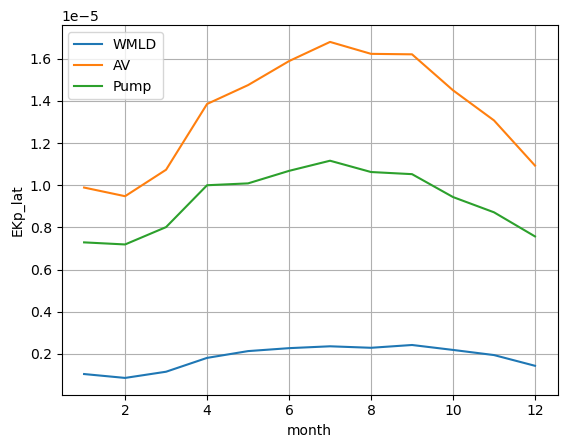

In [61]:
WMLD_mmean.plot(label='WMLD')
AV_mmean.plot(label='AV')
Pump_mmean.plot(label='Pump')
# HUI_mmean.plot(label='HUI')
plt.grid(True)
plt.legend()

In [62]:
## Normalize the Indices
## Indices 
WMLD_mmonth_normal = normalize(WMLD_mmean)
AV_mmonth_normal = normalize(AV_mmean)
CUI_mmonth_normal=normalize(CUI_mmean)
Pump_mmonth_normal=normalize(Pump_mmean)
Ekt_mmonth_normal=normalize(Ekt_mmean)
HUI_mmonth_normal=normalize(HUI_mmean)
CUTI_mmonth_normal=normalize(CUTI_mmean)
BEUTI_mmonth_normal=normalize(BEUTI_mmean)
BUI_mmonth_normal=normalize(BUI_mmean)

In [63]:
time = np.linspace(1,12,12)

UI_dic = {
    # 'time':time,
    '$W_{MLD}$':WMLD_mmonth_normal.values,
    'AV':AV_mmonth_normal.values,
    'CUI':CUI_mmonth_normal.values,
    'Pump':Pump_mmonth_normal.values,
    'ET':Ekt_mmonth_normal.values,
    # 'HUI':HUI_mmonth_normal.values,
    'CUTI':CUTI_mmonth_normal.values,
    'BEUTI':BEUTI_mmonth_normal.values,
    'BUI':BUI_mmonth_normal.values
}

normalized_mmonth = pd.DataFrame(UI_dic)
normalized_mmonth


,$W_{MLD}$,AV,CUI,Pump,ET,CUTI,BEUTI,BUI
0,0.117787,0.056020,0.174466,0.024817,0.112301,0.095302,0.084224,0.099325
1,0.000000,0.000000,0.323109,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.188222,0.171512,0.543672,0.207253,0.124496,0.127687,0.066787,0.128642
3,0.608430,0.597744,1.000000,0.707215,0.478002,0.477251,0.467575,0.476102
4,0.814494,0.720080,0.936597,0.729370,0.708462,0.715849,0.742664,0.702763
5,0.903850,0.875735,0.603316,0.878913,0.860403,0.879367,0.877560,0.865127
6,0.960377,1.000000,0.311130,1.000000,0.986138,0.999143,0.989150,0.993795
7,0.915158,0.922693,0.145992,0.864948,0.973383,0.979211,1.000000,0.975730
8,1.000000,0.919564,0.033061,0.839552,1.000000,1.000000,0.984091,1.000000
9,0.850159,0.686486,0.008908,0.566074,0.828073,0.817077,0.800469,0.816278


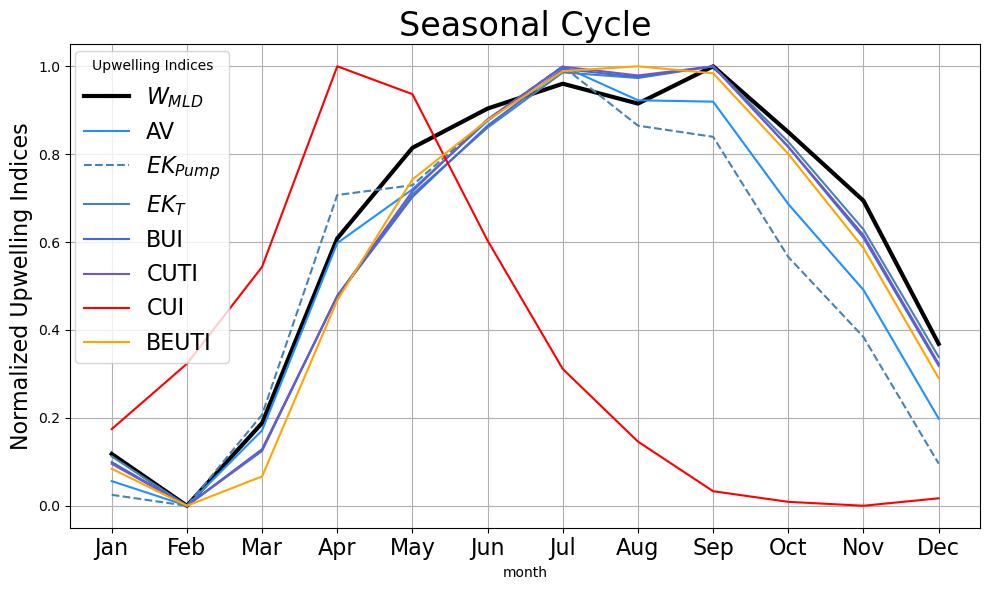

In [102]:
plt.figure(figsize=(10, 6))

WMLD_mmonth_normal.plot(color='black',linewidth=3,label='$W_{MLD}$') 
AV_mmonth_normal.plot(color='dodgerblue',label='AV')
Pump_mmonth_normal.plot(color='steelblue',linestyle='dashed',label='$EK_{Pump}$')
Ekt_mmonth_normal.plot(color='steelblue',linestyle='solid',label='$EK_{T}$')
BUI_mmonth_normal.plot(color='royalblue',label='BUI')
# HUI_mmonth_normal.plot()
CUTI_mmonth_normal.plot(color='slateblue',label='CUTI')
CUI_mmonth_normal.plot(color='red',label='CUI')
BEUTI_mmonth_normal.plot(color='orange',label='BEUTI')

plt.ylabel('Normalized Upwelling Indices',fontsize=16)
plt.title('Seasonal Cycle',fontsize=24)
plt.grid(True)
plt.legend()

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(1, 13), months,fontsize=16)  # Assuming your data has 12 points (one per month)

plt.legend(
    title='Upwelling Indices',
    loc='upper center',       # Position at top-center
    bbox_to_anchor=(0.09, 1.01
                   ),  # Center horizontally (x=0.5), just below top (y=1)
    ncol=1,  # Number of columns = number of legend items
    frameon=True,           # Remove legend border (optional)
    fontsize=16            # Adjust font size
)

plt.tight_layout()  # Prevent label clipping
# plt.savefig('Figures/Seasonal_cycle_poster'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')

plt.show()

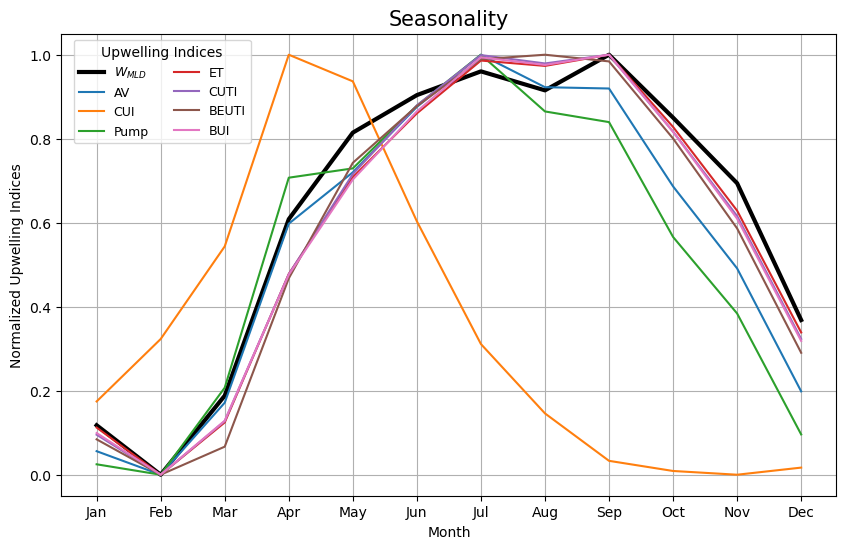

In [269]:
# import matplotlib.pyplot as plt
normalized_df=normalized_mmonth
# Assuming normalized_df.index contains integer values representing months (1 for January, 2 for February, etc.)

# Create the figure
plt.figure(figsize=(10, 6))

# Plot the first column with a solid black line
first_column = normalized_df.columns[0]
plt.plot(normalized_df.index, normalized_df[first_column], label=first_column, color='black', linestyle='-', linewidth=3)

# Iterate over the remaining columns and plot each variable
for column in normalized_df.columns[1:]:
    plt.plot(normalized_df.index, normalized_df[column], label=column)

# Manually specify the positions and labels for the x-axis ticks
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(normalized_df.index, months)

plt.xlabel('Month')
plt.ylabel('Normalized Upwelling Indices')
plt.title('Seasonality',fontsize=15)
# plt.legend(title='Upwelling Indices', bbox_to_anchor=(1, 1))
plt.legend(
    title='Upwelling Indices',
    loc='upper center',       # Position at top-center
    bbox_to_anchor=(0.13, 1),  # Center horizontally (x=0.5), just below top (y=1)
    ncol=2,  # Number of columns = number of legend items
    frameon=True,           # Remove legend border (optional)
    fontsize=9             # Adjust font size
)

plt.grid(True)

# plt.savefig('Figures/Season_normalized_poster'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')

plt.show()

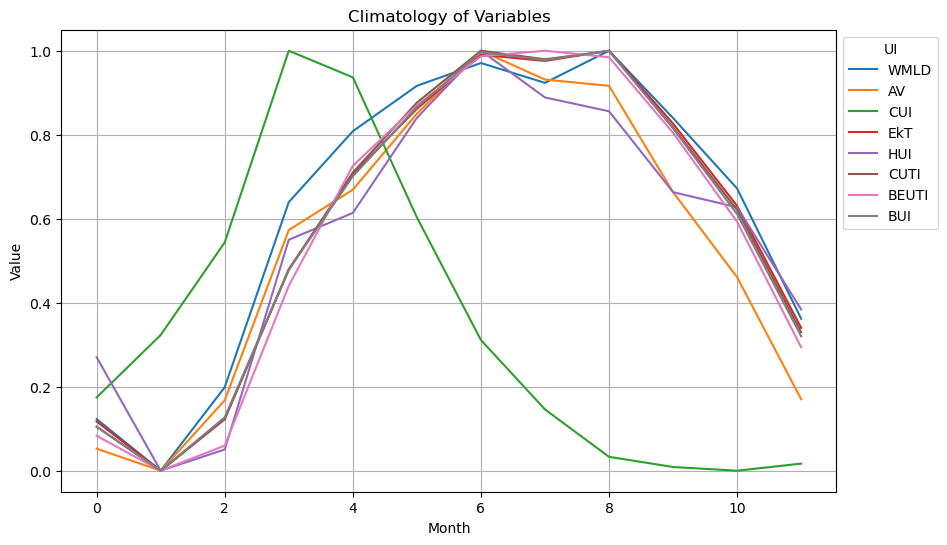

In [58]:
import matplotlib.pyplot as plt

# Assuming 'climatology' is your DataFrame containing the climatology data
plt.figure(figsize=(10, 6))

# Iterate over columns and plot each variable
for column in normalized_mmonth.columns:
    plt.plot(normalized_mmonth.index, normalized_mmonth[column], label=column)

plt.xlabel('Month')
plt.ylabel('Value')
plt.title('Climatology of Variables')
plt.legend(title='UI', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

## Interannual variability

In [119]:
## gathering the monthly mean 
time = pd.date_range(start="1980-01",end="2016-01",freq='M')

UI_monthly = {
    # 'time':time,
    'WMLD':WMLD_ds_['WMLD'].mean(dim='lat', skipna=True).values,
    'AV':AV_ds['AV'].mean(dim='lat',skipna=True).values,
    'CUI':CUI_cut.mean(dim='lat', skipna=True).values,
    'Pump':EK_ds['EKp_lat'].mean(dim='lat', skipna=True).values,
    'ET':EK_ds['EKt_lat'].mean(dim='lat', skipna=True).values,
    'HUI':HUI_ds['HUI'].mean(dim='lat',skipna=True).values,
    'CUTI':CUTI_ds['CUTI'].mean(dim='lat', skipna=True).values,
    'BEUTI':BEUTI_ds['BEUTI'].mean(dim='lat', skipna=True).values,
    'BUI':BUI_ds['BUI'].mean(dim='lat', skipna=True).values
}


UI_monthly_inter = pd.DataFrame(UI_monthly)
UI_monthly_inter.index = time

# Extract month and year from the time index
UI_monthly_inter['month'] = UI_monthly_inter.index.month
UI_monthly_inter['year'] = UI_monthly_inter.index.year

UI_monthly_inter

/tmp/ipykernel_1974220/2248248078.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start="1980-01",end="2016-01",freq='M')


,WMLD,AV,CUI,Pump,ET,HUI,CUTI,BEUTI,BUI,month,year
1980-01-31,1.001335e-06,0.000009,2.721126,0.000007,1.359061,0.000009,1.549218,14.589463,0.078381,1,1980
1980-02-29,8.618142e-07,0.000009,3.058046,0.000007,1.285973,0.000008,1.504561,12.760376,0.074254,2,1980
1980-03-31,9.075809e-07,0.000010,3.572625,0.000008,1.402103,0.000008,1.660205,14.896884,0.081063,3,1980
1980-04-30,1.387553e-06,0.000013,3.700169,0.000009,1.971805,0.000010,2.237604,28.379732,0.113409,4,1980
1980-05-31,2.112006e-06,0.000015,4.336253,0.000010,2.452073,0.000012,2.697024,45.536857,0.141353,5,1980
...,...,...,...,...,...,...,...,...,...,...,...
2015-08-31,1.845185e-06,0.000015,2.203553,0.000010,3.038198,0.000011,3.202610,63.753114,0.171865,8,2015
2015-09-30,1.738915e-06,0.000014,1.577053,0.000009,2.708107,0.000010,2.907761,51.593990,0.152425,9,2015
2015-10-31,1.977907e-06,0.000015,2.020351,0.000010,2.957931,0.000012,3.176899,54.335914,0.166776,10,2015
2015-11-30,1.752101e-06,0.000015,1.408531,0.000009,3.036741,0.000011,3.298905,50.466679,0.168758,11,2015


In [120]:
indices = UI_monthly_inter.columns[:9]
magnitud = pd.DataFrame(['m/s','m/s','[°C]','m/s','m2/s','m/s','m2/s','mmol m/s','m2/s'])
magnitud.index = indices
magnitud

,0
WMLD,m/s
AV,m/s
CUI,[°C]
Pump,m/s
ET,m2/s
HUI,m/s
CUTI,m2/s
BEUTI,mmol m/s
BUI,m2/s


/tmp/ipykernel_1974220/1754312459.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(
/tmp/ipykernel_1974220/1754312459.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[i].set_ylabel(magnitud[0][i])
/tmp/ipykernel_1974220/1754312459.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(
/tmp/ipykernel_1974220/1754312459.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[i].set_ylabel(magnitud[0][i])
/tmp/ipykernel_1974220/1754312459.py:16: FutureWarning: 

The `ci` parameter is 

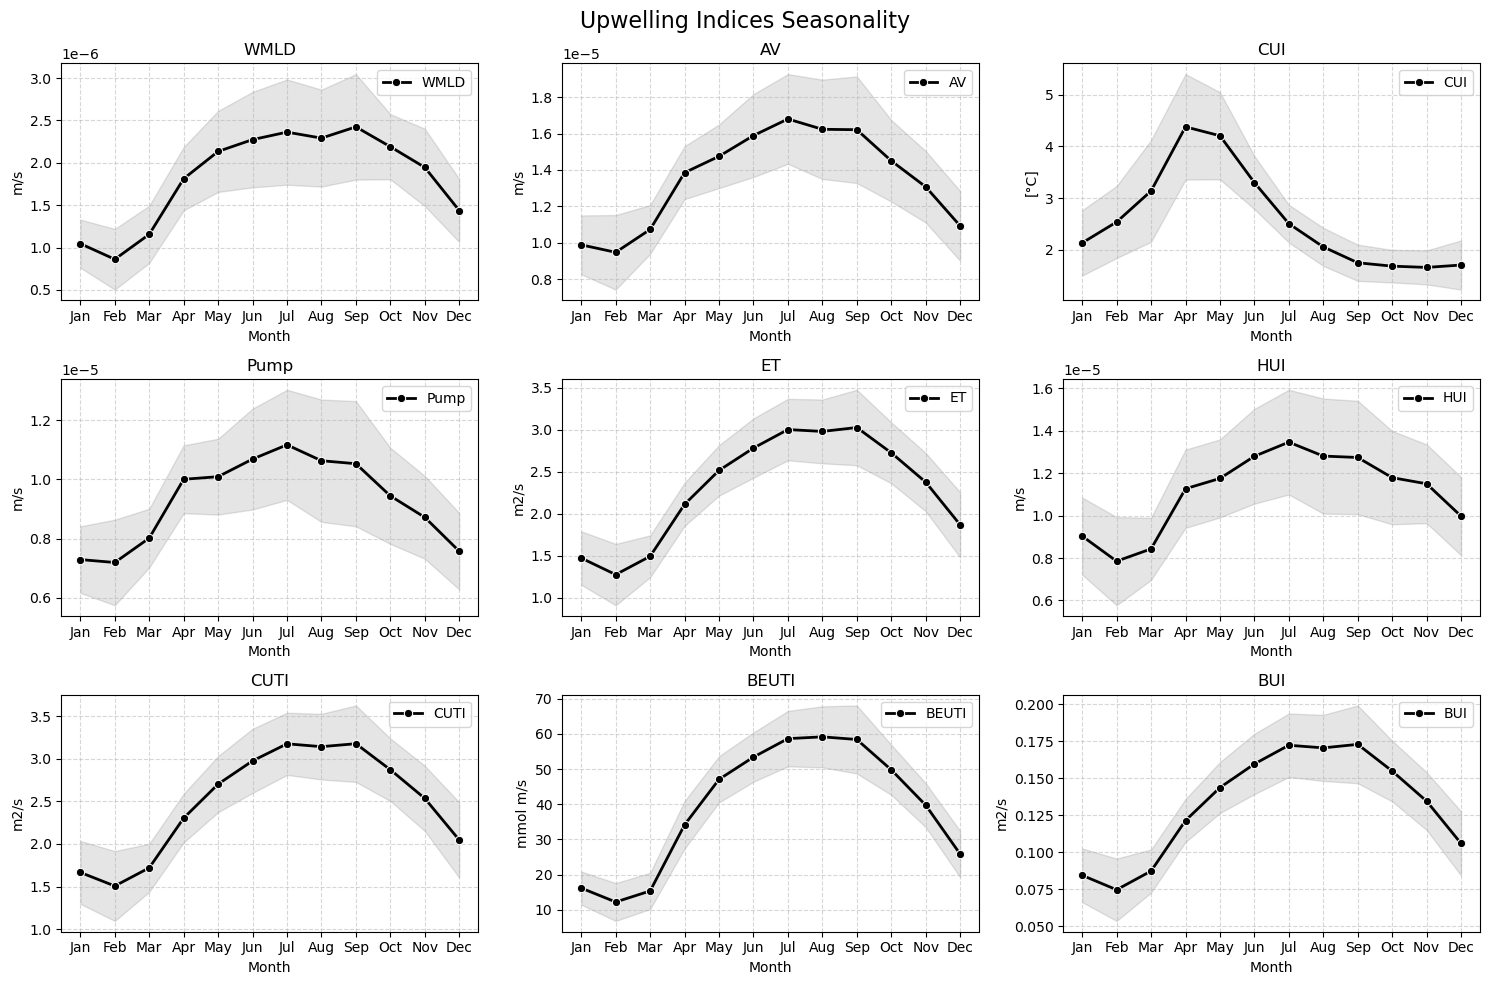

In [121]:
# import matplotlib.pyplot as plt
import seaborn as sns

# Define the indices (first 9 columns)
indices = UI_monthly_inter.columns[:9]

# Create a subplot grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))  # 3x3 grid for 9 plots
fig.suptitle('Upwelling Indices Seasonality', fontsize=16)  # Overall title

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Iterate over the indices and plot each column in a separate subplot
for i, key in enumerate(indices):
    sns.lineplot(
        data=UI_monthly_inter, 
        x='month', 
        y=key, 
        ci='sd', 
        marker='o', 
        color='black', 
        err_kws={'alpha': 0.1},
        linewidth=2, 
        label=key,
        ax=axes[i]  # Plot on the corresponding subplot
    )
    
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].set_title(key)  # Set the title of the subplot to the column name
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel(magnitud[0][i])
    axes[i].set_xticks(range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])


# Adjust layout to prevent overlap
plt.tight_layout()
# plt.savefig('Figures/Seasonality_months'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

In [122]:
import seaborn as sns

sns.lineplot(
    data=wmld_df, 
    x='month', 
    y='WMLD', 
    ci='sd', 
    marker='o', 
    color='Black', 
        err_kws={'alpha': 0.1},
    linewidth=2
)

plt.grid(True, linestyle='--', alpha=0.5)

# Customize the plot
plt.title('Seasonality of WMLD')
plt.xlabel('Month')
plt.ylabel('WMLD (m)')
plt.xticks(range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Show the plot
plt.tight_layout()
plt.show()

NameError: name 'wmld_df' is not defined

### Normalization

In [123]:
CUI_norm=normalize(CUI_anomaly.rolling(time=13,center=True).mean())
Pump_norm=normalize(Pump_anomaly.rolling(time=13,center=True).mean())
Ekt_norm=normalize(Ekt_anomaly.rolling(time=13,center=True).mean())
AV_norm=normalize(AV_anomaly.rolling(time=13,center=True).mean())
HUI_norm=normalize(HUI_anomaly.rolling(time=13,center=True).mean())
CUTI_norm=normalize(CUTI_anomaly.rolling(time=13,center=True).mean())
BEUTI_norm=normalize(BEUTI_anomaly.rolling(time=13,center=True).mean())
BUI_norm=normalize(BUI_anomaly.rolling(time=13,center=True).mean())
WMLD_norm=normalize(WMLD_anomaly.rolling(time=13,center=True).mean())

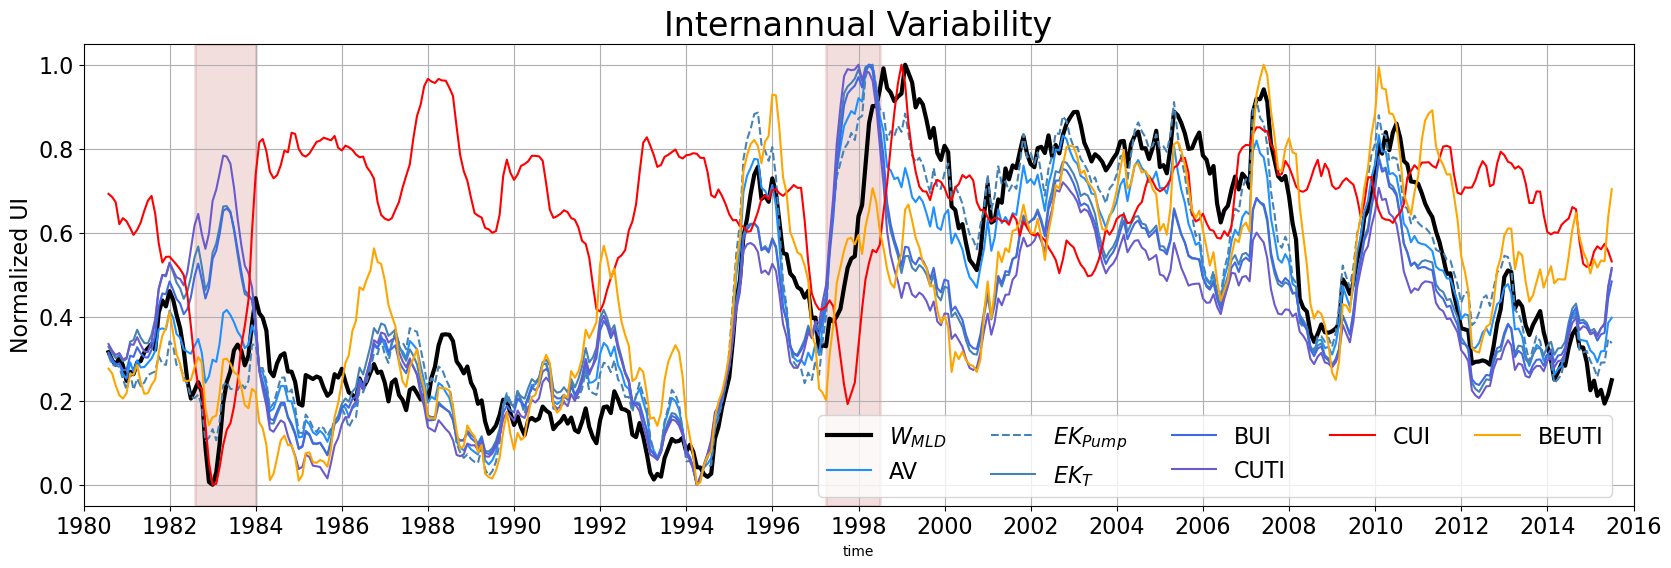

In [141]:
import matplotlib.dates as mdates
import datetime
from matplotlib.patches import Rectangle
plt.figure(figsize=(20, 6))

WMLD_norm.plot(color='black',linewidth=3,label='$W_{MLD}$') 
AV_norm.plot(color='dodgerblue',label='AV')
Pump_norm.plot(color='steelblue',linestyle='dashed',label='$EK_{Pump}$')
Ekt_norm.plot(color='steelblue',linestyle='solid',label='$EK_{T}$')
BUI_norm.plot(color='royalblue',label='BUI')
# HUI_mmonth_normal.plot()
CUTI_norm.plot(color='slateblue',label='CUTI')
CUI_norm.plot(color='red',label='CUI')
BEUTI_norm.plot(color='orange',label='BEUTI')

plt.ylabel('Normalized UI',fontsize=16)
plt.title('Internannual Variability',fontsize=24)
# plt.legend(title='Upwelling Indices', bbox_to_anchor=(1, 1))
plt.legend(
    title='',
    loc='upper center',
    bbox_to_anchor=(0.73, 0.22),
    ncol=5,
    frameon=True,
    fontsize=16
)

ax = plt.gca()
#rectangle 1
start_date = datetime.datetime(1982, 8, 1)
end_date = datetime.datetime(1983, 12, 31)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

#rectangle 2
start_date = datetime.datetime(1997, 4, 1)
end_date = datetime.datetime(1998, 6, 30)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

# Set x-axis limits
plt.xlim([mdates.date2num(datetime.datetime(1980, 1, 1)), 
          mdates.date2num(datetime.datetime(2016, 1, 1))])

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))  # Grid lines every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format years as 'YYYY'

ax.tick_params(axis='both', which='major', labelsize=16)
plt.grid(visible=True, which='major')

# plt.savefig('Figures/Interannual_variability_poster'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

In [300]:
time = pd.date_range(start="1980-01",end="2016-01",freq='M')

UI_dic_inter = {
    # 'time':time,
    '$W_{MLD}$':WMLD_norm.values,
    'AV':AV_norm.values,
    'CUI':CUI_norm.values,
    'Pump':Pump_norm.values,
    'ET':Ekt_norm.values,
    # 'HUI':HUI_norm.values,
    'CUTI':CUTI_norm.values,
    'BEUTI':BEUTI_norm.values,
    'BUI':BUI_norm.values
}

normalized_UI = pd.DataFrame(UI_dic_inter)
normalized_UI.index = time
normalized_UI

/tmp/ipykernel_2736616/934476916.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start="1980-01",end="2016-01",freq='M')


,$W_{MLD}$,AV,CUI,Pump,ET,CUTI,BEUTI,BUI
1980-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-02-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2015-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-10-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-11-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


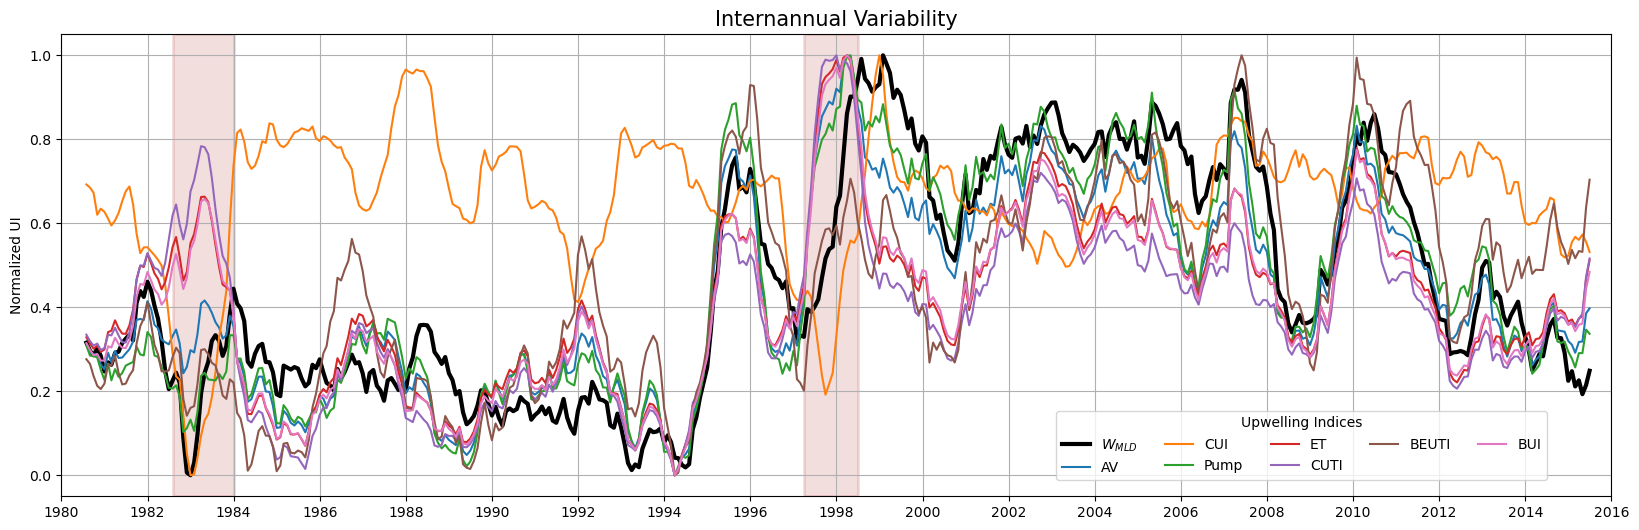

In [349]:
# Assuming 'climatology' is your DataFrame containing the climatology data
import matplotlib.dates as mdates
import datetime
from matplotlib.patches import Rectangle

plt.figure(figsize=(20, 6))

# Plot the first column with a solid black line
first_column = normalized_UI.columns[0]
plt.plot(normalized_UI.index, normalized_UI[first_column], label=first_column, color='black', linestyle='-', linewidth=3)

# Iterate over columns and plot each variable
for column in normalized_UI.columns[1:]:
    plt.plot(normalized_UI.index, normalized_UI[column], label=column)

# plt.xlabel('Month')
plt.ylabel('Normalized UI')
plt.title('Internannual Variability',fontsize=15)
# plt.legend(title='Upwelling Indices', bbox_to_anchor=(1, 1))
plt.legend(
    title='Upwelling Indices',
    loc='upper center',
    bbox_to_anchor=(0.8, 0.2),
    ncol=5,
    frameon=True,
    fontsize=10
)

ax = plt.gca()
#rectangle 1
start_date = datetime.datetime(1982, 8, 1)
end_date = datetime.datetime(1983, 12, 31)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

#rectangle 2
start_date = datetime.datetime(1997, 4, 1)
end_date = datetime.datetime(1998, 6, 30)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

# Set x-axis limits
plt.xlim([mdates.date2num(datetime.datetime(1980, 1, 1)), 
          mdates.date2num(datetime.datetime(2016, 1, 1))])

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))  # Grid lines every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format years as 'YYYY'
plt.grid(visible=True, which='major')

# plt.savefig('Figures/Interannual_variability_poster'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

## ENSO 

### 1996-1999

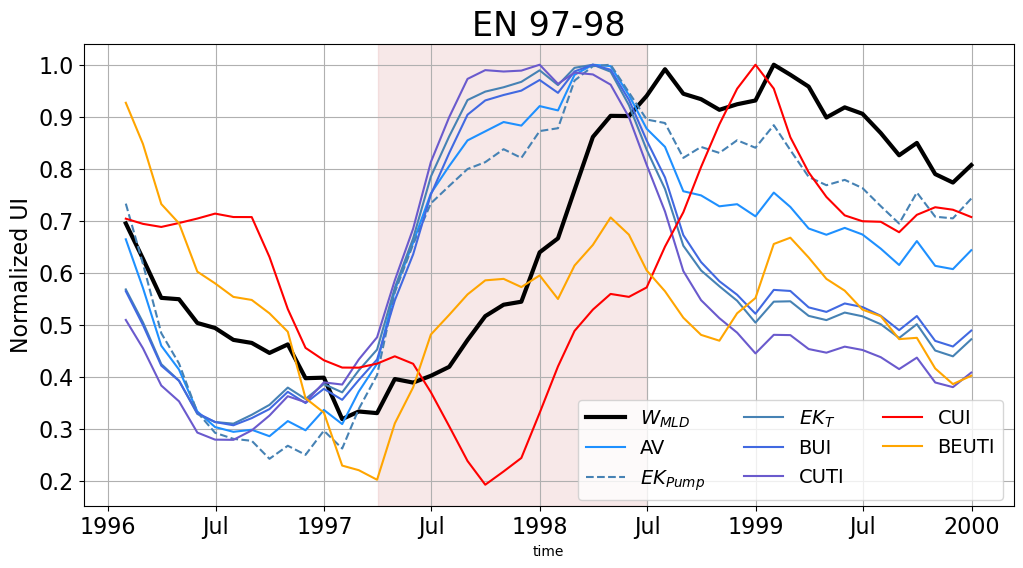

In [168]:
plt.figure(figsize=(12, 6))

WMLD_norm.sel(time=slice("1996-01-01","1999-12-31")).plot(color='black',linewidth=3,label='$W_{MLD}$') 
AV_norm.sel(time=slice("1996-01-01","1999-12-31")).plot(color='dodgerblue',label='AV')
Pump_norm.sel(time=slice("1996-01-01","1999-12-31")).plot(color='steelblue',linestyle='dashed',label='$EK_{Pump}$')
Ekt_norm.sel(time=slice("1996-01-01","1999-12-31")).plot(color='steelblue',linestyle='solid',label='$EK_{T}$')
BUI_norm.sel(time=slice("1996-01-01","1999-12-31")).plot(color='royalblue',label='BUI')
# HUI_mmonth_normal.plot()
CUTI_norm.sel(time=slice("1996-01-01","1999-12-31")).plot(color='slateblue',label='CUTI')
CUI_norm.sel(time=slice("1996-01-01","1999-12-31")).plot(color='red',label='CUI')
BEUTI_norm.sel(time=slice("1996-01-01","1999-12-31")).plot(color='orange',label='BEUTI')

ax = plt.gca()
ymin, ymax = ax.get_ylim()

# Rectangle for ENSO 1997-98 (Apr 1997 - Jun 1998)
start_date = datetime.datetime(1997, 4, 1)
end_date = datetime.datetime(1998, 6, 30)
rect = Rectangle(
    (mdates.date2num(start_date), ymin),  # Convert to matplotlib date format
    mdates.date2num(end_date) - mdates.date2num(start_date),  # Width
    ymax - ymin,  # Height
    linewidth=1,
    edgecolor='firebrick',
    facecolor='firebrick',
    linestyle='-',
    alpha=0.1
)
ax.add_patch(rect)

ax.legend(
    title='',
    loc='upper center',
    bbox_to_anchor=(0.76, 0.25),
    ncol=3,
    frameon=True,
    fontsize=14
)

ax.tick_params(axis='both', which='major', labelsize=16)
# plt.xlabel('Month')
plt.ylabel('Normalized UI',fontsize=16)
plt.title('EN 97-98',fontsize=24)
# plt.legend(title='Upwelling Indices', bbox_to_anchor=(1, 1))
plt.grid(visible=True, which='major')

# plt.savefig('Figures/ENSO_97_98_poster'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

In [376]:
# BUI_norm.sel(time=slice("1996-01-01","1998-12-31")).plot()

time_ENSO = pd.date_range(start="1996-01",end="2000-01",freq='M')

UI_dic_ENSO = {
    # 'time':time,
    '$W_{MLD}$':WMLD_norm.sel(time=slice("1996-01-01","1999-12-31")).values,
    'AV':AV_norm.sel(time=slice("1996-01-01","1999-12-31")).values,
    'CUI':CUI_norm.sel(time=slice("1996-01-01","1999-12-31")).values,
    'Pump':Pump_norm.sel(time=slice("1996-01-01","1999-12-31")).values,
    'ET':Ekt_norm.sel(time=slice("1996-01-01","1999-12-31")).values,
    # 'HUI':HUI_norm.sel(time=slice("1996-01-01","1999-12-31")).values,
    'CUTI':CUTI_norm.sel(time=slice("1996-01-01","1999-12-31")).values,
    'BEUTI':BEUTI_norm.sel(time=slice("1996-01-01","1999-12-31")).values,
    'BUI':BUI_norm.sel(time=slice("1996-01-01","1999-12-31")).values
}

normalized_UI_ENSO = pd.DataFrame(UI_dic_ENSO)
normalized_UI_ENSO.index = time_ENSO
normalized_UI_ENSO

/tmp/ipykernel_2736616/4102706435.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time_ENSO = pd.date_range(start="1996-01",end="2000-01",freq='M')


,$W_{MLD}$,AV,CUI,Pump,ET,CUTI,BEUTI,BUI
1996-01-31,0.694649,0.664118,0.703771,0.732740,0.567691,0.508960,0.926782,0.564232
1996-02-29,0.626773,0.570537,0.693800,0.616859,0.504440,0.454512,0.847548,0.499238
1996-03-31,0.551433,0.459363,0.687874,0.483543,0.423920,0.382744,0.731950,0.421010
1996-04-30,0.548822,0.413476,0.695453,0.425176,0.392111,0.352355,0.694850,0.391777
1996-05-31,0.503091,0.332747,0.704011,0.331278,0.328046,0.292225,0.601859,0.329783
1996-06-30,0.493459,0.302846,0.713520,0.291786,0.312551,0.278636,0.579332,0.312468
1996-07-31,0.470568,0.293668,0.706951,0.280148,0.309370,0.278250,0.553267,0.306281
1996-08-31,0.464723,0.297664,0.706850,0.276412,0.326439,0.296410,0.547402,0.320013
1996-09-30,0.445470,0.285222,0.630141,0.241730,0.345556,0.324992,0.521687,0.337446
1996-10-31,0.461871,0.314356,0.529915,0.266914,0.378768,0.362178,0.486227,0.370638


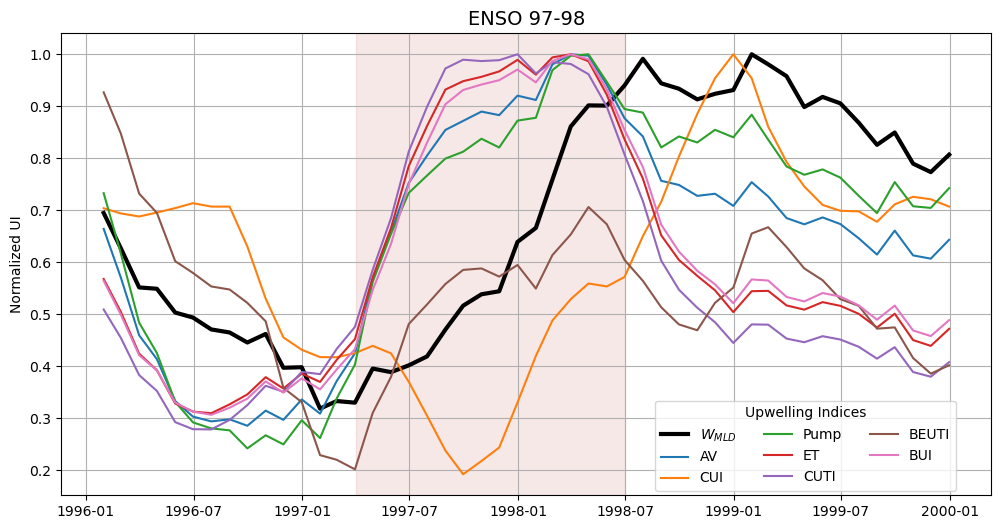

In [377]:
plt.figure(figsize=(12, 6))

# Plot the first column with a solid black line
first_column = normalized_UI_ENSO.columns[0]
plt.plot(normalized_UI_ENSO.index, normalized_UI_ENSO[first_column], label=first_column, color='black', linestyle='-', linewidth=3)

# Iterate over columns and plot each variable
for column in normalized_UI_ENSO.columns[1:]:
    plt.plot(normalized_UI_ENSO.index, normalized_UI_ENSO[column], label=column)

# Set up the rectangle for ENSO 1997-98 event
ax = plt.gca()
ymin, ymax = ax.get_ylim()

# Rectangle for ENSO 1997-98 (Apr 1997 - Jun 1998)
start_date = datetime.datetime(1997, 4, 1)
end_date = datetime.datetime(1998, 6, 30)
rect = Rectangle(
    (mdates.date2num(start_date), ymin),  # Convert to matplotlib date format
    mdates.date2num(end_date) - mdates.date2num(start_date),  # Width
    ymax - ymin,  # Height
    linewidth=1,
    edgecolor='firebrick',
    facecolor='firebrick',
    linestyle='-',
    alpha=0.1
)
ax.add_patch(rect)

ax.legend(
    title='Upwelling Indices',
    loc='upper center',
    bbox_to_anchor=(0.8, 0.22),
    ncol=3,
    frameon=True,
    fontsize=10
)

# plt.xlabel('Month')
plt.ylabel('Normalized UI')
plt.title('ENSO 97-98',fontsize=14)
# plt.legend(title='Upwelling Indices', bbox_to_anchor=(1, 1))
plt.grid(visible=True, which='major')

# plt.savefig('Figures/IA_ENSO_97_98_poster'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

### 1981-1984

In [368]:
# BUI_norm.sel(time=slice("1996-01-01","1998-12-31")).plot()

time_ENSO = pd.date_range(start="1981-01",end="1985-01",freq='M')

UI_dic_ENSO = {
    # 'time':time,
    'WMLD':WMLD_norm.sel(time=slice("1981-01-01","1984-12-31")).values,
    'AV':AV_norm.sel(time=slice("1981-01-01","1984-12-31")).values,
    'CUI':CUI_norm.sel(time=slice("1981-01-01","1984-12-31")).values,
    'Pump':Pump_norm.sel(time=slice("1981-01-01","1984-12-31")).values,
    'ET':Ekt_norm.sel(time=slice("1981-01-01","1984-12-31")).values,
    # 'HUI':HUI_norm.sel(time=slice("1981-01-01","1984-12-31")).values,
    'CUTI':CUTI_norm.sel(time=slice("1981-01-01","1984-12-31")).values,
    'BEUTI':BEUTI_norm.sel(time=slice("1981-01-01","1984-12-31")).values,
    'BUI':BUI_norm.sel(time=slice("1981-01-01","1984-12-31")).values
}

normalized_UI_ENSO = pd.DataFrame(UI_dic_ENSO)
normalized_UI_ENSO.index = time_ENSO
normalized_UI_ENSO

/tmp/ipykernel_2736616/3901132875.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time_ENSO = pd.date_range(start="1981-01",end="1985-01",freq='M')


,WMLD,AV,CUI,Pump,ET,CUTI,BEUTI,BUI
1981-01-31,0.268942,0.291525,0.610972,0.266000,0.340768,0.334678,0.264898,0.307253
1981-02-28,0.263116,0.269118,0.594869,0.226109,0.344331,0.333029,0.261607,0.304310
1981-03-31,0.291244,0.296185,0.606779,0.252660,0.368908,0.351289,0.285099,0.327390
1981-04-30,0.294194,0.279269,0.624448,0.234406,0.349931,0.332866,0.243945,0.312790
1981-05-31,0.315155,0.280318,0.652634,0.243484,0.337364,0.317001,0.216238,0.303681
1981-06-30,0.325226,0.289958,0.676200,0.261128,0.336781,0.316144,0.218290,0.302810
1981-07-31,0.335048,0.300315,0.687620,0.265641,0.356904,0.340139,0.237389,0.320911
1981-08-31,0.321150,0.318373,0.645223,0.269667,0.394944,0.389680,0.250556,0.356026
1981-09-30,0.410591,0.370051,0.574764,0.306323,0.466784,0.465599,0.313852,0.424831
1981-10-31,0.438627,0.372173,0.528978,0.287597,0.499041,0.499365,0.355197,0.455296


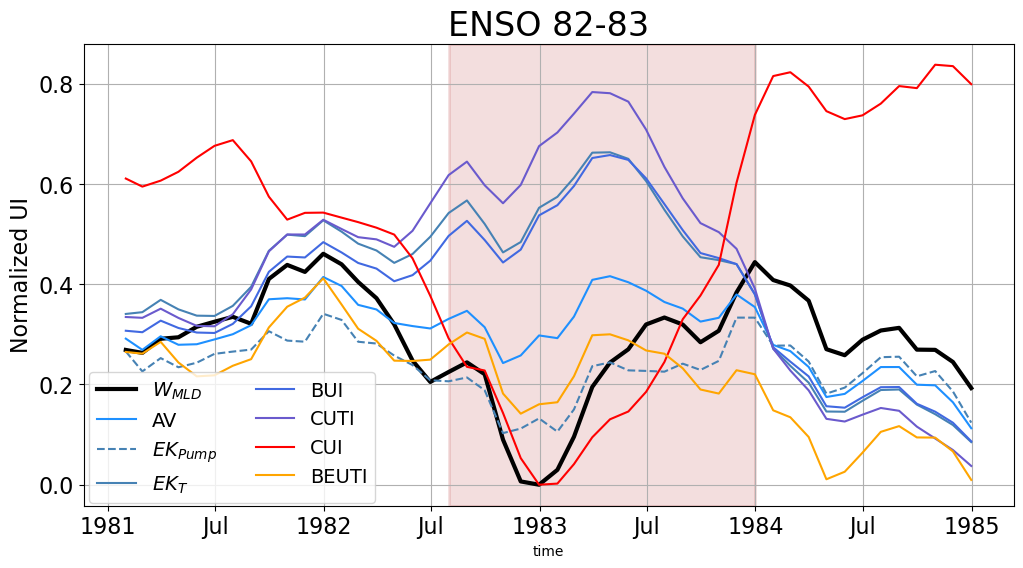

In [186]:
plt.figure(figsize=(12, 6))
WMLD_norm.sel(time=slice("1981-01-01","1984-12-31")).plot(color='black',linewidth=3,label='$W_{MLD}$') 
AV_norm.sel(time=slice("1981-01-01","1984-12-31")).plot(color='dodgerblue',label='AV')
Pump_norm.sel(time=slice("1981-01-01","1984-12-31")).plot(color='steelblue',linestyle='dashed',label='$EK_{Pump}$')
Ekt_norm.sel(time=slice("1981-01-01","1984-12-31")).plot(color='steelblue',linestyle='solid',label='$EK_{T}$')
BUI_norm.sel(time=slice("1981-01-01","1984-12-31")).plot(color='royalblue',label='BUI')
# HUI_mmonth_normal.plot()
CUTI_norm.sel(time=slice("1981-01-01","1984-12-31")).plot(color='slateblue',label='CUTI')
CUI_norm.sel(time=slice("1981-01-01","1984-12-31")).plot(color='red',label='CUI')
BEUTI_norm.sel(time=slice("1981-01-01","1984-12-31")).plot(color='orange',label='BEUTI')

ax = plt.gca()
ymin, ymax = ax.get_ylim()

ax = plt.gca()
#rectangle 1
start_date = datetime.datetime(1982, 8, 1)
end_date = datetime.datetime(1983, 12, 31)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

ax.legend(
    title='',
    loc='upper center',
    bbox_to_anchor=(0.16, 0.31),
    ncol=2,
    frameon=True,
    fontsize=14
)

ax.tick_params(axis='both', which='major', labelsize=16)
# plt.xlabel('Month')
plt.ylabel('Normalized UI',fontsize=16)
plt.title('ENSO 82-83',fontsize=24)
# plt.legend(title='Upwelling Indices', bbox_to_anchor=(1, 1))
plt.grid(True)
# plt.savefig('Figures/ENSO_82_83_poster'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

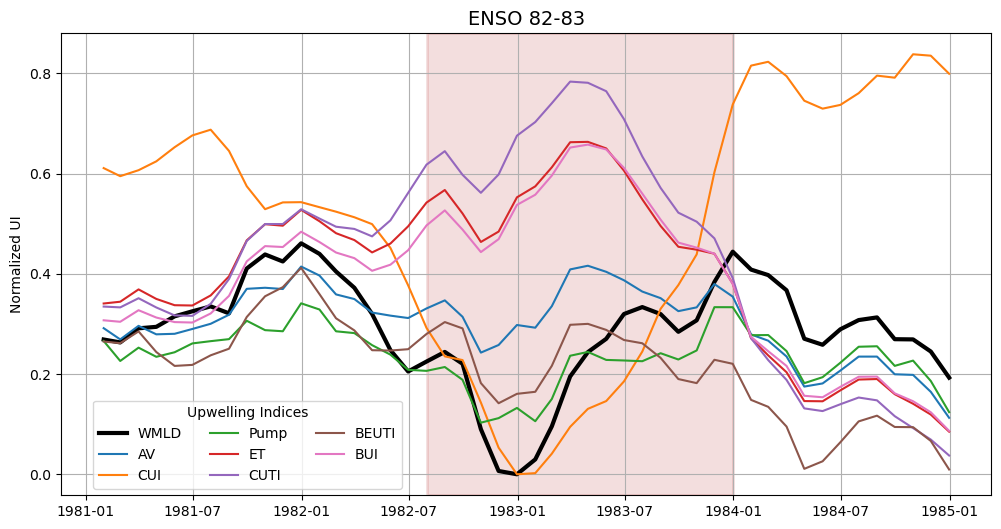

In [374]:
plt.figure(figsize=(12, 6))

# Plot the first column with a solid black line
first_column = normalized_UI_ENSO.columns[0]
plt.plot(normalized_UI_ENSO.index, normalized_UI_ENSO[first_column], label=first_column, color='black', linestyle='-', linewidth=3)

# Iterate over columns and plot each variable
for column in normalized_UI_ENSO.columns[1:]:
    plt.plot(normalized_UI_ENSO.index, normalized_UI_ENSO[column], label=column)

# Set up the rectangle for ENSO 1997-98 event
ax = plt.gca()
ymin, ymax = ax.get_ylim()

ax = plt.gca()
#rectangle 1
start_date = datetime.datetime(1982, 8, 1)
end_date = datetime.datetime(1983, 12, 31)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

ax.legend(
    title='Upwelling Indices',
    loc='upper center',
    bbox_to_anchor=(0.2, 0.22),
    ncol=3,
    frameon=True,
    fontsize=10
)


# plt.xlabel('Month')
plt.ylabel('Normalized UI')
plt.title('ENSO 82-83',fontsize=14)
# plt.legend(title='Upwelling Indices', bbox_to_anchor=(1, 1))
plt.grid(True)

# plt.savefig('Figures/IA_ENSO_82_83_poster'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

## Correlations

### Seasonal

In [378]:
corr_matrix = round(normalized_mmonth.corr(method='pearson'),2)
print(corr_matrix)

           $W_{MLD}$    AV   CUI  Pump    ET  CUTI  BEUTI   BUI
$W_{MLD}$       1.00  0.98 -0.01  0.93  0.99  0.99   0.99  0.99
AV              0.98  1.00  0.09  0.98  0.97  0.98   0.98  0.98
CUI            -0.01  0.09  1.00  0.25 -0.11 -0.09  -0.07 -0.10
Pump            0.93  0.98  0.25  1.00  0.92  0.92   0.93  0.92
ET              0.99  0.97 -0.11  0.92  1.00  1.00   1.00  1.00
CUTI            0.99  0.98 -0.09  0.92  1.00  1.00   1.00  1.00
BEUTI           0.99  0.98 -0.07  0.93  1.00  1.00   1.00  1.00
BUI             0.99  0.98 -0.10  0.92  1.00  1.00   1.00  1.00


<Axes: >

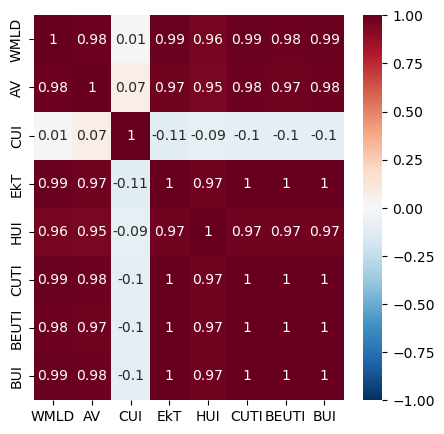

In [64]:
import seaborn as sn

fig=plt.figure(figsize=(5,5))
sn.heatmap(corr_matrix, annot=True,cmap="RdBu_r", vmin=-1, vmax=1)

### Interannual

In [379]:
# normalized_UI
corr_matrix_inter = round(normalized_UI.corr(method='pearson'),2)
print(corr_matrix_inter)

           $W_{MLD}$    AV   CUI  Pump    ET  CUTI  BEUTI   BUI
$W_{MLD}$       1.00  0.91  0.08  0.93  0.76  0.66   0.78  0.78
AV              0.91  1.00 -0.17  0.98  0.93  0.86   0.82  0.94
CUI             0.08 -0.17  1.00 -0.02 -0.46 -0.58  -0.03 -0.44
Pump            0.93  0.98 -0.02  1.00  0.84  0.76   0.81  0.86
ET              0.76  0.93 -0.46  0.84  1.00  0.98   0.76  1.00
CUTI            0.66  0.86 -0.58  0.76  0.98  1.00   0.67  0.98
BEUTI           0.78  0.82 -0.03  0.81  0.76  0.67   1.00  0.76
BUI             0.78  0.94 -0.44  0.86  1.00  0.98   0.76  1.00


### Year

In [381]:
CUI_yr=CUI_cut.mean(dim='lat', skipna=True).groupby('time.year').mean(dim='time',skipna=True)
Pump_yr=EK_ds['EKp_lat'].mean(dim='lat', skipna=True).groupby('time.year').mean(dim='time',skipna=True)
Ekt_yr=Ekt_anomaly.groupby('time.year').mean(dim='time',skipna=True)
AV_yr=AV_ds['AV'].mean(dim='lat',skipna=True).groupby('time.year').mean(dim='time',skipna=True)
HUI_yr=HUI_ds['HUI'].mean(dim='lat',skipna=True).groupby('time.year').mean(dim='time',skipna=True)
CUTI_yr=CUTI_ds['CUTI'].mean(dim='lat', skipna=True).groupby('time.year').mean(dim='time',skipna=True)
BEUTI_yr=BEUTI_ds['BEUTI'].mean(dim='lat', skipna=True).groupby('time.year').mean(dim='time',skipna=True)
BUI_yr=BUI_ds['BUI'].mean(dim='lat', skipna=True).groupby('time.year').mean(dim='time',skipna=True)
WMLD_yr=WMLD_ds_['WMLD'].mean(dim='lat', skipna=True).groupby('time.year').mean(dim='time',skipna=True)

In [382]:
time_yr = pd.date_range(start="1980-01",end="2016-01",freq='Y')

UI_dic_yr = {
    # 'time':time,
    'WMLD':WMLD_yr.values,
    'AV':AV_yr.values,
    'CUI':CUI_yr.values,
    'Pump':Pump_yr.values,
    'EkT':Ekt_yr.values,
    'HUI':HUI_yr.values,
    'CUTI':CUTI_yr.values,
    'BEUTI':BEUTI_yr.values,
    'BUI':BUI_yr.values
}

UI_year = pd.DataFrame(UI_dic_yr)
UI_year.index = time_yr
UI_year

/tmp/ipykernel_2736616/2150093552.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  time_yr = pd.date_range(start="1980-01",end="2016-01",freq='Y')


,WMLD,AV,CUI,Pump,EkT,HUI,CUTI,BEUTI,BUI
1980-12-31,0.000002,0.000013,2.643586,0.000009,-0.093996,0.000010,2.421942,36.524900,0.126132
1981-12-31,0.000002,0.000013,2.635332,0.000009,-0.075304,0.000010,2.406999,35.971251,0.125914
1982-12-31,0.000002,0.000013,1.936943,0.000008,0.103115,0.000010,2.713264,36.464849,0.135435
1983-12-31,0.000002,0.000013,1.685362,0.000009,0.183668,0.000009,2.824470,36.853038,0.143760
1984-12-31,0.000002,0.000012,2.748799,0.000009,-0.227541,0.000010,2.226753,34.166402,0.119485
1985-12-31,0.000002,0.000012,2.896991,0.000008,-0.342548,0.000010,2.072832,33.385529,0.112504
1986-12-31,0.000002,0.000012,2.835100,0.000008,-0.138181,0.000010,2.324644,39.905339,0.122602
1987-12-31,0.000002,0.000013,2.728780,0.000009,-0.093221,0.000011,2.394612,36.484357,0.125143
1988-12-31,0.000002,0.000012,3.131099,0.000008,-0.256033,0.000010,2.175473,35.616778,0.117474
1989-12-31,0.000001,0.000012,2.428279,0.000008,-0.325075,0.000009,2.143096,33.081357,0.113018


In [383]:
corr_matrix_yr = round(UI_year.corr(method='pearson'),2)
print(corr_matrix_yr)

       WMLD    AV   CUI  Pump   EkT   HUI  CUTI  BEUTI   BUI
WMLD   1.00  0.90  0.01  0.92  0.77  0.88  0.66   0.76  0.80
AV     0.90  1.00 -0.23  0.98  0.93  0.95  0.86   0.80  0.95
CUI    0.01 -0.23  1.00 -0.08 -0.49 -0.01 -0.62  -0.02 -0.47
Pump   0.92  0.98 -0.08  1.00  0.85  0.98  0.77   0.79  0.87
EkT    0.77  0.93 -0.49  0.85  1.00  0.80  0.98   0.75  1.00
HUI    0.88  0.95 -0.01  0.98  0.80  1.00  0.70   0.79  0.82
CUTI   0.66  0.86 -0.62  0.77  0.98  0.70  1.00   0.67  0.98
BEUTI  0.76  0.80 -0.02  0.79  0.75  0.79  0.67   1.00  0.76
BUI    0.80  0.95 -0.47  0.87  1.00  0.82  0.98   0.76  1.00


## Stratification

In [187]:
MLD = loadmat("../../NHCS/Processed/WMLD_MLD.mat")
print(MLD.keys())

dict_keys(['__header__', '__version__', '__globals__', 'MLD', 'WMLD'])


In [188]:
# ¨WMLD_MLD
SST = loadmat("../../NHCS/Processed/SST_SSH.mat")
print(SST.keys())

dict_keys(['__header__', '__version__', '__globals__', 'SSH', 'SST'])


In [189]:
# EKMAN_components

Curl = loadmat("../../NHCS/Processed/EKMAN_components.mat")
print(Curl.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Curl', 'Divergence', 'Crosshore_wind', 'VTauy', 'EK_pump', 'UEK', 'VEK', 'LTM_ekpump'])


In [190]:
## mask
print(ds.mask_rho.shape)
mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)
expanded_mask = np.tile(mask_nan[np.newaxis, :, :], (432, 1, 1))
print(expanded_mask.shape)

(542, 602)
(432, 542, 602)


In [191]:
Strat_ds = xr.Dataset(
    data_vars={
        'MLD': (("time", "lat","lon"), MLD['MLD'].transpose(2, 1, 0)*expanded_mask),
        'Curl':(("time", "lat","lon"), Curl['Curl'].transpose(2, 1, 0)*-1),
        'SST':(("time", "lat","lon"), SST['SST'].transpose(2, 1, 0)*expanded_mask),
        'SSH':(("time", "lat","lon"), SST['SSH'].transpose(2, 1, 0)*expanded_mask),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

Strat_ds

<xarray.Dataset> Size: 5GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 1GB 0.9402 0.9402 1.335 ... nan nan nan
    Curl     (time, lat, lon) float64 1GB 2.585e-08 3.833e-08 ... nan nan
    SST      (time, lat, lon) float64 1GB 20.19 20.18 20.24 ... nan nan nan
    SSH      (time, lat, lon) float64 1GB 0.212 0.212 0.2117 ... nan nan nan

In [192]:
Strat_ds_cut = Strat_ds * inshore_mask
Strat_ts = Strat_ds_cut.sel(lat=slice(-16,-5),lon=slice(-84,-73))
Strat_ts

<xarray.Dataset> Size: 245MB
Dimensions:  (lon: 132, lat: 134, time: 432)
Coordinates:
  * lon      (lon) float64 1kB -83.95 -83.87 -83.78 ... -73.2 -73.12 -73.03
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 61MB nan nan nan nan ... nan nan nan nan
    Curl     (time, lat, lon) float64 61MB nan nan nan nan ... nan nan nan nan
    SST      (time, lat, lon) float64 61MB nan nan nan nan ... nan nan nan nan
    SSH      (time, lat, lon) float64 61MB nan nan nan nan ... nan nan nan nan

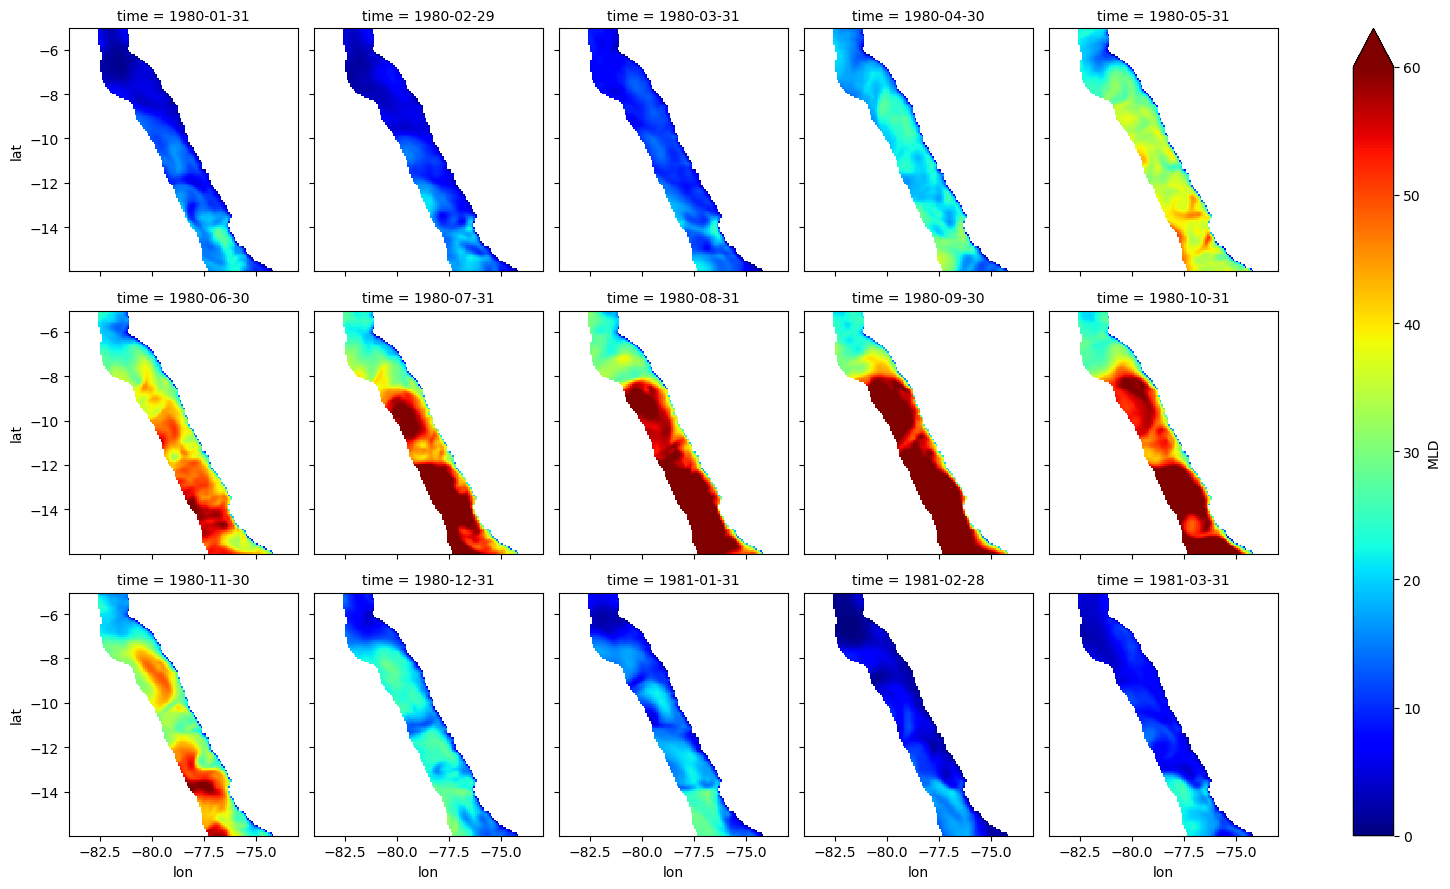

In [103]:
Strat_ts.MLD.isel(time=slice(0,15)).plot(x="lon", y="lat", col="time", col_wrap=5, vmin=0,vmax=60,cmap='jet')

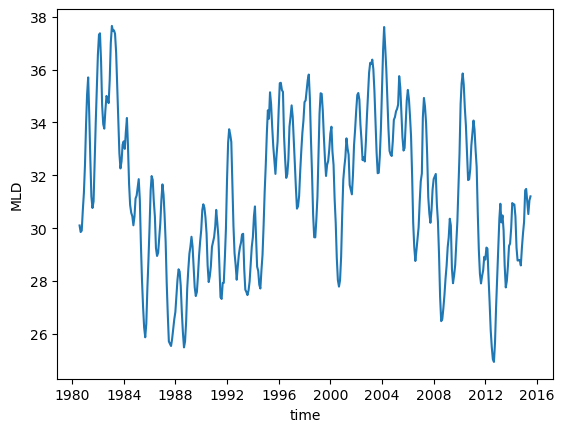

In [104]:
Strat_ts.mean(dim=('lat','lon'),skipna=True).MLD.rolling(time=13,center=True).mean().plot()

In [193]:
strat_mmean = Strat_ts.mean(dim=('lat','lon'),skipna=True).groupby('time.month').mean(dim='time')
strat_anomaly = Strat_ts.mean(dim=('lat','lon'),skipna=True).groupby('time.month') - strat_mmean
strat_anomaly

<xarray.Dataset> Size: 21kB
Dimensions:  (time: 432)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
    month    (time) int64 3kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    MLD      (time) float64 3kB -1.54 -0.7741 -1.98 -1.332 ... 1.42 9.786 13.23
    Curl     (time) float64 3kB -8.475e-09 -3.81e-09 ... 1.123e-08 5.314e-09
    SST      (time) float64 3kB -0.5937 -0.6417 -0.1236 ... 1.324 1.608 1.42
    SSH      (time) float64 3kB 0.0003581 -0.00454 0.01561 ... 0.05618 0.06358

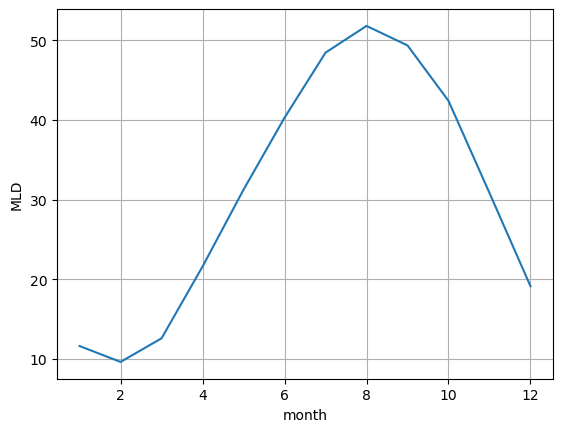

In [391]:
strat_mmean.MLD.plot()
plt.grid(True)

In [194]:
##Normalize
def normalize(data):
    return (data - data.min()) / (data.max() - data.min())

In [195]:
strat_norm = normalize(strat_anomaly.rolling(time=13,center=True).mean())


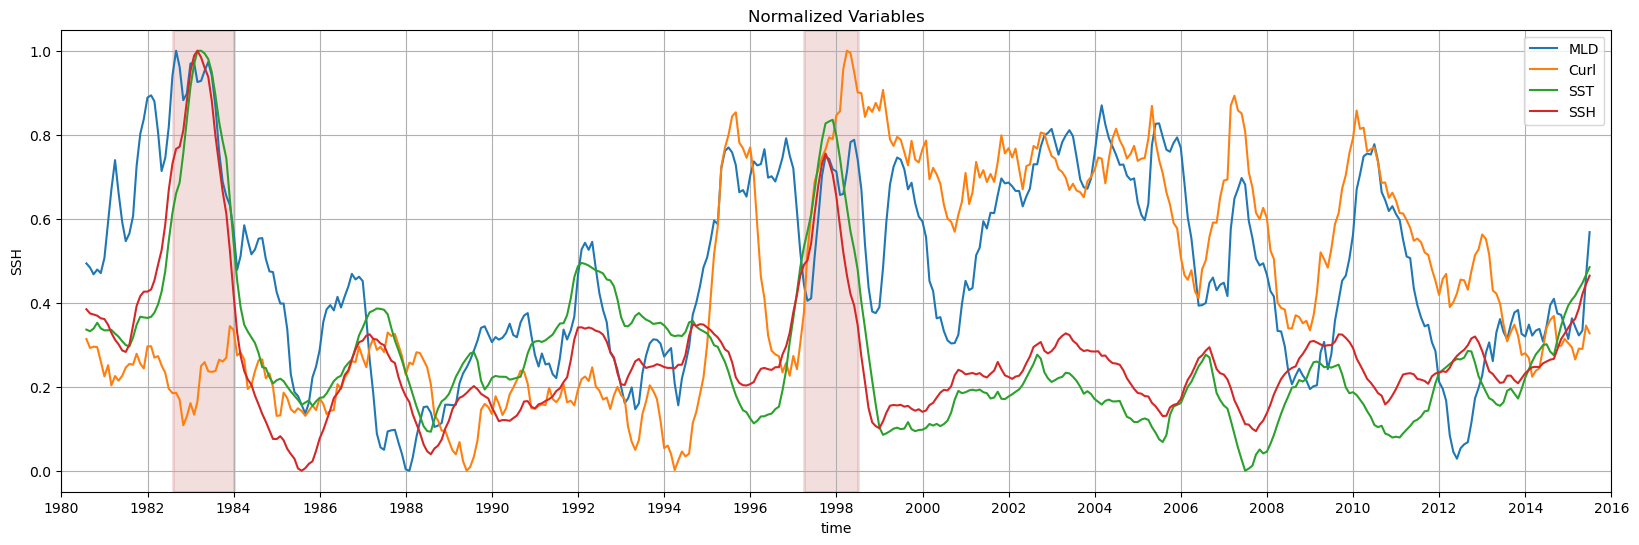

In [411]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,6))

strat_norm.MLD.plot(ax=ax,label='MLD')
strat_norm.Curl.plot(ax=ax,label='Curl')
strat_norm.SST.plot(ax=ax,label='SST')
strat_norm.SSH.plot(ax=ax,label='SSH')

# Add a legend
# fig.legend(title='', bbox_to_anchor=(0.87, 0.9))

ax = plt.gca()
#rectangle 1
start_date = datetime.datetime(1982, 8, 1)
end_date = datetime.datetime(1983, 12, 31)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

#rectangle 2
start_date = datetime.datetime(1997, 4, 1)
end_date = datetime.datetime(1998, 6, 30)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

# Set x-axis limits
plt.xlim([mdates.date2num(datetime.datetime(1980, 1, 1)), 
          mdates.date2num(datetime.datetime(2016, 1, 1))])

ax.xaxis.set_major_locator(mdates.YearLocator(base=2))  # Grid lines every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format years as 'YYYY'
plt.grid(visible=True, which='major')
plt.title('Normalized Variables')
ax.legend(title='', bbox_to_anchor=(1, 1))

# plt.savefig('Figures/ENSO_components'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')


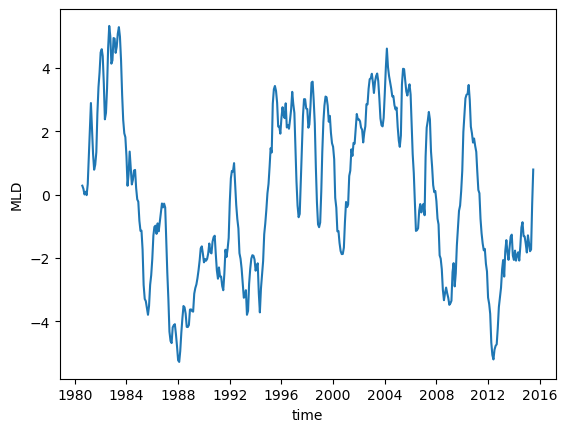

In [110]:
strat_anomaly.MLD.rolling(time=13,center=True).mean().plot()
# strat_anomaly.Curl.rolling(time=13,center=True).mean().plot()
# strat_anomaly.SST.rolling(time=13,center=True).mean().plot()
# strat_anomaly.SSH.rolling(time=13,center=True).mean().plot()

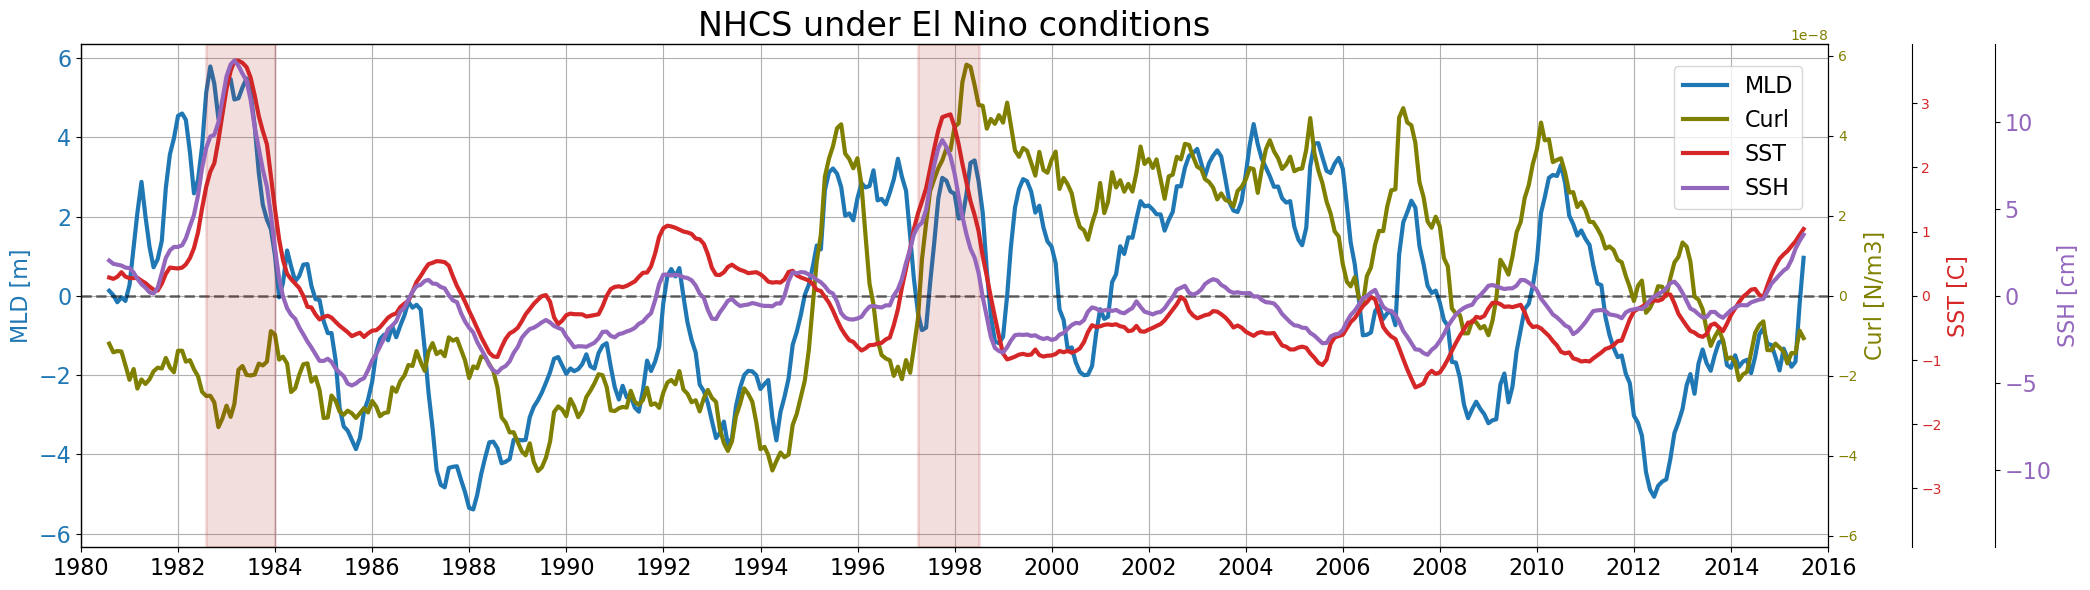

In [215]:
# Assuming strat_anomaly is your dataset
# Compute rolling means for each variable
mld_rolling = strat_anomaly.MLD.rolling(time=13, center=True).mean()
curl_rolling = strat_anomaly.Curl.rolling(time=13, center=True).mean()
sst_rolling = strat_anomaly.SST.rolling(time=13, center=True).mean()
ssh_rolling = strat_anomaly.SSH.rolling(time=13, center=True).mean()*100 #in cm

# Create the figure and first axis
fig, ax1 = plt.subplots(figsize=(21, 6))
# Plot the first variable (MLD) on the first y-axis
color = 'tab:blue'
# ax1.set_xlabel('Time')
ax1.set_ylabel('MLD [m]', color=color,fontsize=16)
ax1.plot(mld_rolling.time, mld_rolling, color=color, label='MLD',linewidth=3)
ax1.tick_params(axis='y', labelcolor=color)

ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)

ax1 = plt.gca()
ax1.xaxis.set_major_locator(mdates.YearLocator(base=2))  # Grid lines every 2 years
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format years as 'YYYY'
ax1.grid(visible=True, which='major')
# Create a second y-axis and plot the second variable (Curl)
ax2 = ax1.twinx()
color = 'olive'
ax2.set_ylabel('Curl [N/m3]', color=color,fontsize=16)
ax2.plot(curl_rolling.time, curl_rolling, color=color, label='Curl',linewidth=3)
ax2.tick_params(axis='y', labelcolor=color)

# Create a third y-axis and plot the third variable (SST)
ax3 = ax1.twinx()
color = 'tab:red'
ax3.spines['right'].set_position(('outward', 60))  # Offset the third axis
ax3.set_ylabel('SST [C]', color=color,fontsize=16)
ax3.plot(sst_rolling.time, sst_rolling, color=color, label='SST',linewidth=3)
ax3.tick_params(axis='y', labelcolor=color)

# Create a fourth y-axis and plot the fourth variable (SSH)
ax4 = ax1.twinx()
color = 'tab:purple'
ax4.spines['right'].set_position(('outward', 120))  # Offset the fourth axis
ax4.set_ylabel('SSH [cm]', color=color,fontsize=16)
ax4.plot(ssh_rolling.time, ssh_rolling, color=color, label='SSH',linewidth=3)
ax4.tick_params(axis='y', labelcolor=color)

# Align the y-axes so that 0 coincides
def align_y_axes_at_zero(axes):
    """Align the y-axes of multiple axes so that 0 coincides."""
    for ax in axes:
        y_min, y_max = ax.get_ylim()
        # Calculate the maximum absolute value to ensure 0 is centered
        max_abs = max(abs(y_min), abs(y_max))
        ax.set_ylim(-max_abs, max_abs)

align_y_axes_at_zero([ax1, ax2, ax3, ax4])

# Plot a horizontal line at 0
ax1.axhline(0, color='black', linestyle='--', linewidth=2, alpha=0.5)

# Add a legend
fig.legend(
    title='',
    loc='upper center',
    bbox_to_anchor=(0.83, 0.9),
    ncol=1,
    frameon=True,
    fontsize=16
)

ax = plt.gca()
#rectangle 1
start_date = datetime.datetime(1982, 8, 1)
end_date = datetime.datetime(1983, 12, 31)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

#rectangle 2
start_date = datetime.datetime(1997, 4, 1)
end_date = datetime.datetime(1998, 6, 30)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)
ax.tick_params(axis='both', which='major', labelsize=16)

# Set x-axis limits
plt.xlim([mdates.date2num(datetime.datetime(1980, 1, 1)), 
          mdates.date2num(datetime.datetime(2016, 1, 1))])



# Adjust layout
plt.title('NHCS under El Nino conditions',fontsize=24)
fig.tight_layout()
# plt.savefig('Figures/Stratification_anomalies_poster'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()